# Interpreting and Communicating Statistical Models

In this notebook, we work out a example of how to interpret and communicate statistical models. We follow the ideas and techniques from the amazing book ["Model to Meaning: How to Interpret Statistical Models with marginaleffects for R and Python "](https://marginaleffects.com/). This exposition is by no means exhaustive, but it should give you a good starting point. For more details, check the book!

## Motivating Example: Ads, ROAS and Budgets

The following example is motivated by real applications in the ad-tech industry. We keep it simple, as we are not interested in a detailed statistical model, but rather in the interpretation and communication of the model results:
An ad platform offers advertising services to stores (say, to promote their products). It charges its stores per click and reports back ROAS (return on ad spend). The business strategy is that these stores are paying to get *incremental orders*. Stores keep spending while ROAS makes the campaigns worth it; when it doesn't, they pause for a month(s). The ad platform wants to predict next month's budget from this month's signals: ROAS, where the store is in its life-cycle, and the time of year. Their analytics team has seen that these factors are meaningful to explain the store's engagement to keep investing. One main question is the relationship between ROAS and budget. ROAS larger than one is good for the stores. Less than one simply means that the campaign is not profitable. One could wonder if the bidding algorithm should just push high ROAS on the marketplace to make it healthy and profitable. Nevertheless, the ad platform has seen that very high ROAS often leads to a drop in the following month's budget. The reasons is simple: as the stores have a fixed daily production capacity, they can just serve a limited number of orders. Hence, we expect a non-linear relationship between ROAS and next month's budget.

For this example, we generate synthetic data to mimic the mechanism described above. We generate a panel dataset for $100$ stores.  We'll fit three models of increasing flexibility on the same panel (a Gaussian linear baseline, a Hurdle-Gamma GLM with a linear ROAS coefficient, and a Hurdle-Gamma GLM with a Gaussian process on ROAS) to better understand the relationship between ROAS and next month's budget. We will do this using [`bambi`](https://bambinos.github.io/bambi/) to specify the models and the [`marginaleffects`](https://marginaleffects.com/) framework to interpret the results.

**Warning:** This is a oversimplified example. We are ignoring canibalization, other drivers and a more complex causal structure. In practice, this problem is much harder.

## Prepare Notebook

In [1]:
from typing import NamedTuple

import arviz as az
import bambi as bmb
import marginaleffects.sanitize  # noqa: F401
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from marginaleffects.datagrid import datagrid

az.style.use("arviz-darkgrid")
plt.rcParams["figure.figsize"] = [10, 6]
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "white"

%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = "retina"

In [2]:
seed: int = sum(map(ord, "marginaleffects"))
rng: np.random.Generator = np.random.default_rng(seed=seed)

## Data Generation Process

Let's start by generating the data. As budgets are positive, we model them through a gamma distribution.  On the log scale, next month's expected budget is simulated as follows:

$$
\log \mu_{t+1} \;=\; \beta_0 \;+\; \text{season}(\text{month}_t) \;+\; \gamma \cdot \text{cohort\_age}_t \;+\; \beta(\text{roas}_t) \cdot g(\text{month}_t, \text{cohort\_age}_t) \cdot \text{roas}_t
$$

- The first terms are the intercept, a seasonal effect, and a cohort effect. These are classical additive terms.
- The interesting piece is $\beta(\text{roas})$: a coefficient that varies with ROAS itself. Below $\text{ROAS}=1$ stores are losing money, so the marginal effect of ROAS on next month's budget is negative; in the sweet spot between 1 and 4 each extra unit of ROAS pulls more budget in; past $\text{ROAS}=4$ stores hit inventory or capacity ceilings and the effect saturates.
- The term $g(\text{month}_t, \text{cohort\_age}_t)$ is just a funky interaction term that we use to generate some additional non-linearity.

### A smooth $\beta(\text{roas})$ by construction

We build $\beta$ as a product of two analytic pieces (a smooth rise and a smooth saturation window), so the function is $C^{\infty}$ everywhere with no joining knots.

In [3]:
def beta_roas(roas: np.ndarray) -> np.ndarray:
    rise = -0.5 + 1.0 / (1.0 + np.exp(-3.0 * (roas - 1.0)))
    saturation = 1.0 / (1.0 + np.exp(0.6 * (roas - 4.0)))
    return rise * saturation


def f_roas(roas: np.ndarray) -> np.ndarray:
    return beta_roas(roas) * roas

Let's visualize the $\beta(\text{roas})$ function and the product $\beta(\text{roas}) \cdot \text{roas}$:

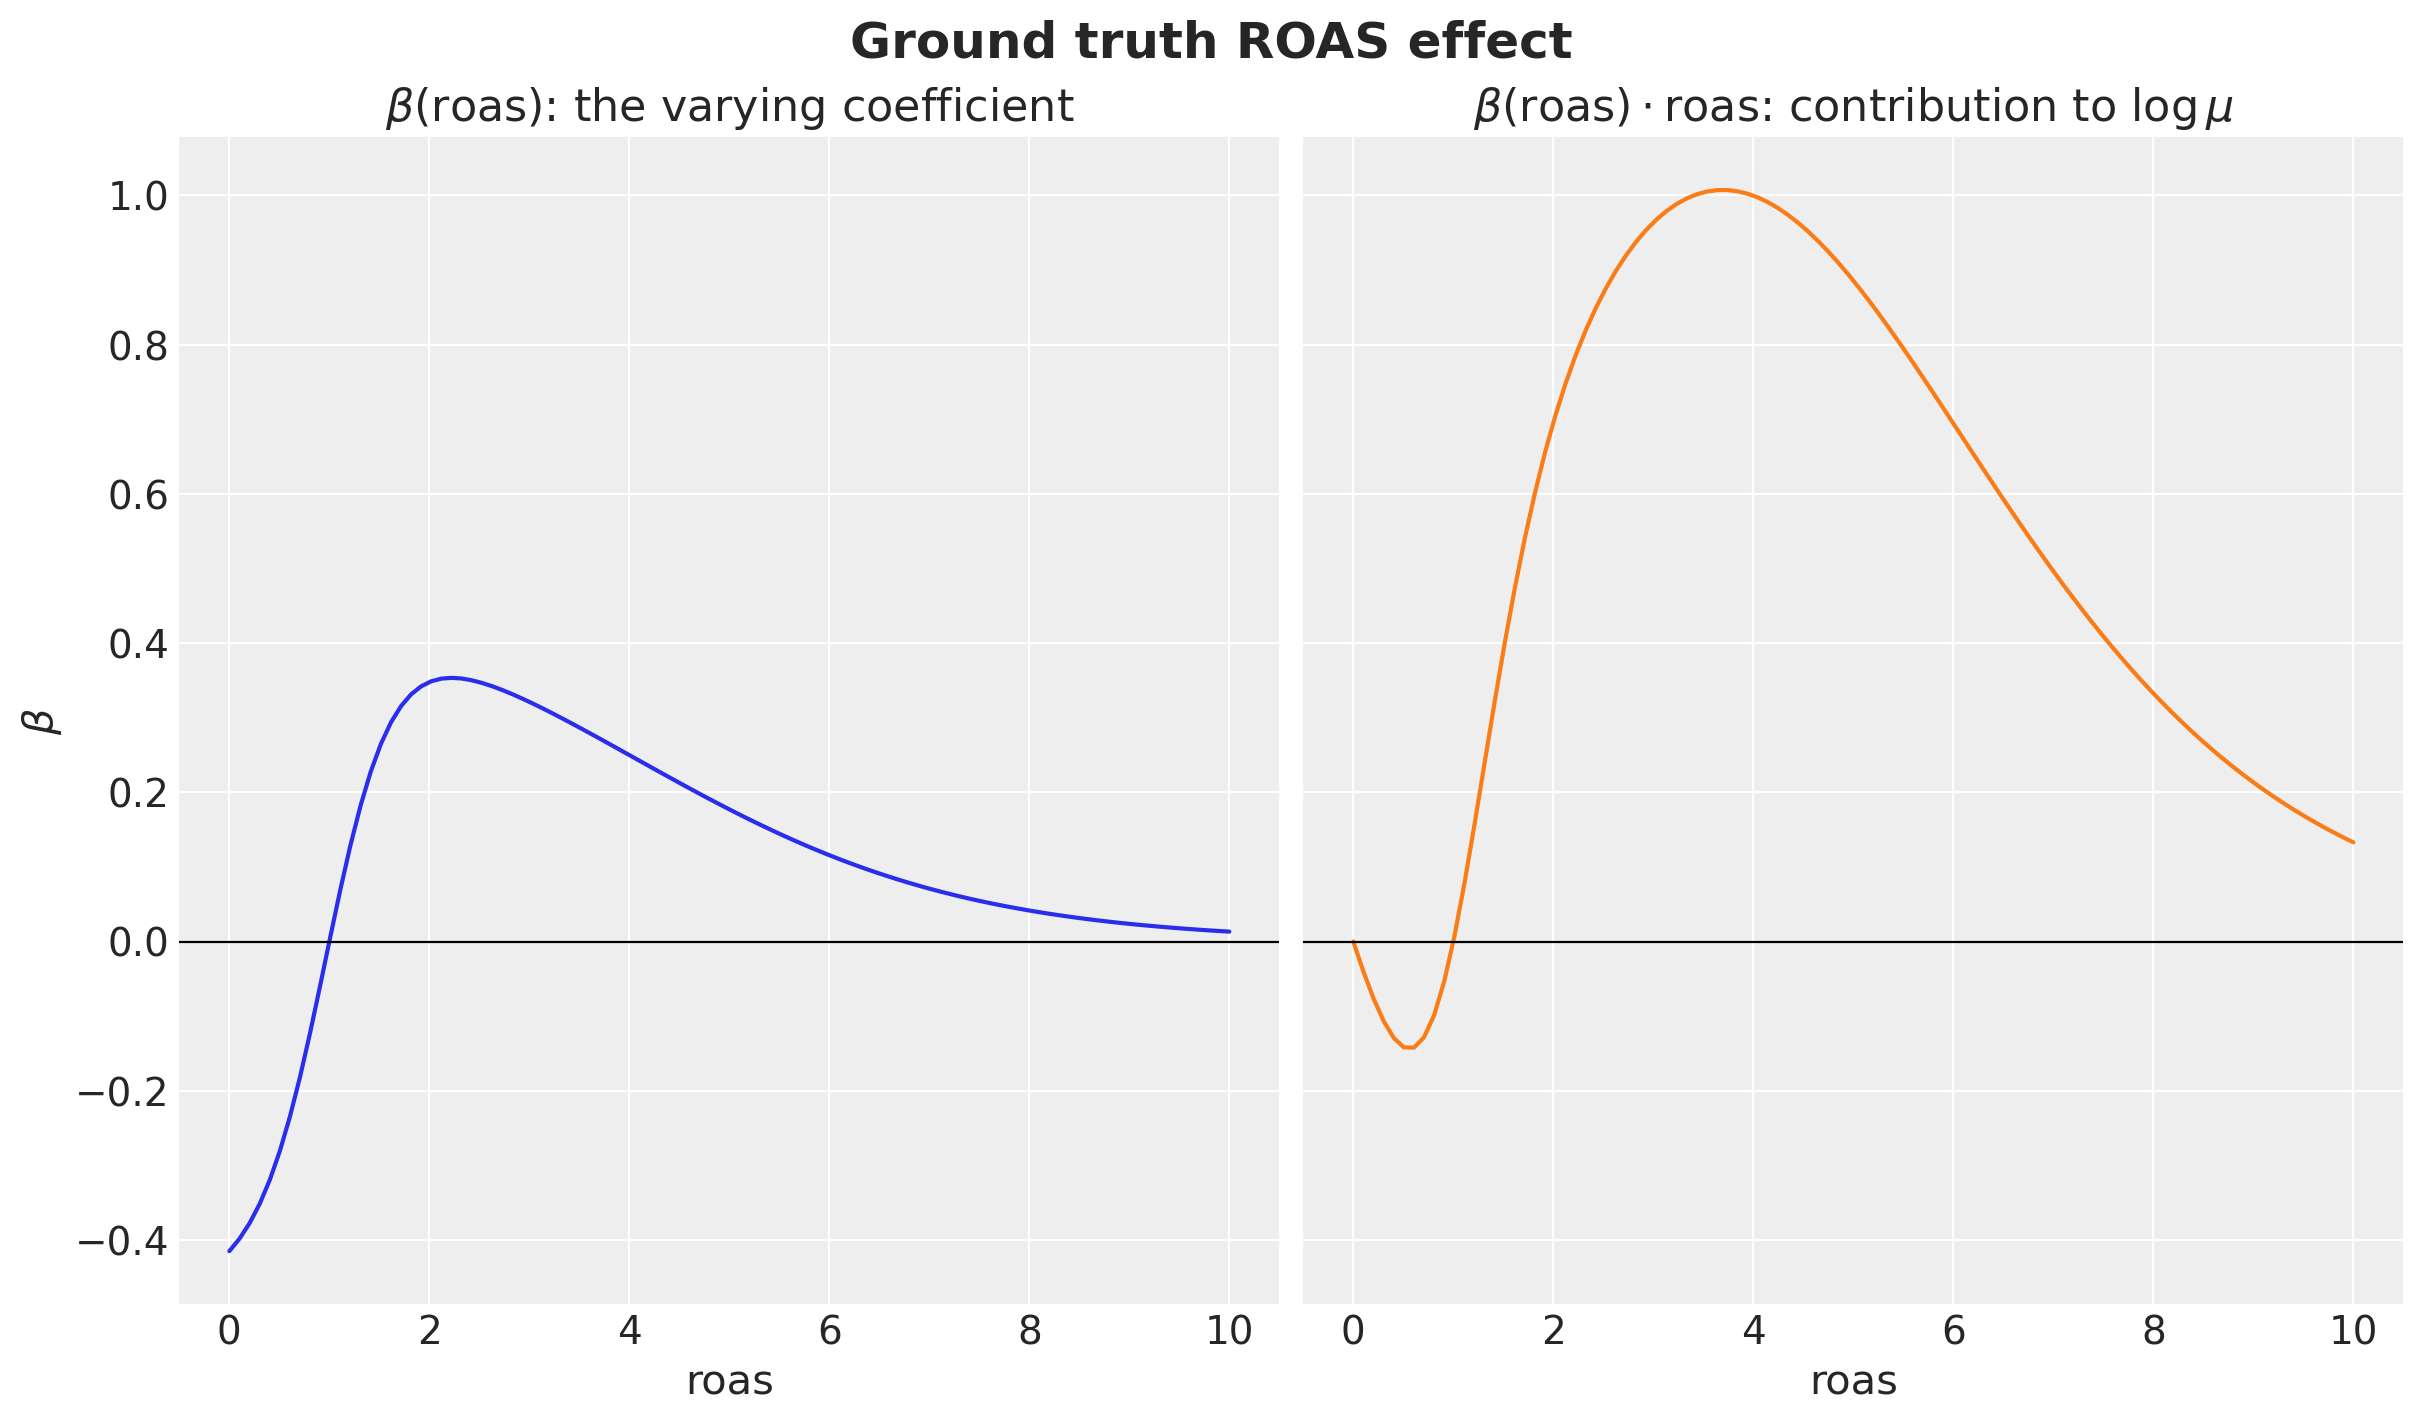

In [4]:
roas_grid = np.linspace(0.0, 10.0, 100)

beta_roas_grid = beta_roas(roas_grid)
f_roas_grid = f_roas(roas_grid)

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(12, 7),
    sharex=True,
    sharey=True,
    layout="constrained",
)
axes[0].plot(roas_grid, beta_roas_grid, color="C0")
axes[0].axhline(0.0, color="black", linewidth=0.8)
axes[0].set(
    title=r"$\beta(\mathrm{roas})$: the varying coefficient",
    xlabel="roas",
    ylabel=r"$\beta$",
)

axes[1].plot(roas_grid, f_roas_grid, color="C1")
axes[1].axhline(0.0, color="black", linewidth=0.8)
axes[1].set(
    title=r"$\beta(\mathrm{roas}) \cdot \mathrm{roas}$: contribution to $\log \mu$",
    xlabel="roas",
)
fig.suptitle("Ground truth ROAS effect", fontsize=18, fontweight="bold");

Negative for low ROAS, rising through zero around break-even, peaking in the sweet spot, then pulled back toward zero as the platform saturates. This is the curve we'll later try to recover from a Gaussian process.

### Generating the Panel Data

We consider $100$ stores observed for $24$ months. Each store has its own cohort start (so cohort age varies across the panel) and its own ROAS process

**Remark:** The lag matters! Each row pairs **this month's signals** with **next month's budget**, the leading indicators a store could act on. When a store is inactive in a given month (no spend), it has no ROAS to report; that's encoded as `NaN`, and rows whose lagged ROAS is `NaN` are dropped at modelling time.

In [5]:
class DGPParams(NamedTuple):
    """Parameters of the synthetic data-generating process.

    Attributes
    ----------
    n_stores
        Number of stores in the panel.
    n_months
        Number of months observed per store.
    intercept
        Baseline contribution to $\\log \\mu$ (response mean on the log scale).
    cohort_slope
        Per-month slope on $\\log \\mu$ for cohort age; older stores drift down.
    gamma_sigma
        Relative noise scale for the Gamma response (coefficient of variation).
        Per-row standard deviation is $\\sigma = \\text{gamma\\_sigma} \\cdot \\mu$,
        so shape $= 1 / \\text{gamma\\_sigma}^2$ is constant across rows. The default
        $1/\\sqrt{8}$ matches the original `gamma_shape = 8` parameterisation.
    inactive_base_prob
        Per-month baseline probability that a store has no spend at all (the
        zero point-mass in the response).
    inactive_summer_bonus
        Extra inactivity probability layered on top of the baseline in July
        and August (a seasonal dip in active stores).
    """

    n_stores: int = 100
    n_months: int = 24
    intercept: float = 0.5
    cohort_slope: float = -0.02
    gamma_sigma: float = 1.0 / np.sqrt(8.0)
    inactive_base_prob: float = 0.05
    inactive_summer_bonus: float = 0.10


class DGP:
    def __init__(self, rng: np.random.Generator) -> None:
        self.rng = rng

    @staticmethod
    def season(month_of_year: np.ndarray) -> np.ndarray:
        return 0.4 * np.sin(2 * np.pi * month_of_year / 12) + 0.2 * np.cos(
            4 * np.pi * month_of_year / 12
        )

    def _simulate_features(
        self, params: DGPParams
    ) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
        store_ids = np.arange(params.n_stores)
        store_starts = self.rng.integers(low=-12, high=1, size=params.n_stores)
        store_log_roas_mean = self.rng.normal(
            loc=np.log(2.5), scale=0.4, size=params.n_stores
        )

        log_roas = np.empty(shape=(params.n_stores, params.n_months))
        log_roas[:, 0] = store_log_roas_mean + self.rng.normal(
            scale=0.3, size=params.n_stores
        )
        for t in range(1, params.n_months):
            log_roas[:, t] = (
                0.6 * log_roas[:, t - 1]
                + 0.4 * store_log_roas_mean
                + self.rng.normal(scale=0.3, size=params.n_stores)
            )
        roas = np.clip(np.exp(log_roas), 0.0, 8.0)

        month_idx = np.broadcast_to(
            np.arange(params.n_months), (params.n_stores, params.n_months)
        )
        month_of_year = (month_idx % 12) + 1
        cohort_age = month_idx - store_starts[:, None]

        inactive_prob = params.inactive_base_prob + params.inactive_summer_bonus * (
            np.isin(month_of_year, [7, 8])
        ).astype(float)
        inactive = (
            self.rng.uniform(size=(params.n_stores, params.n_months)) < inactive_prob
        )

        return roas, month_of_year, cohort_age, store_ids, inactive

    def _draw_response(
        self,
        roas: np.ndarray,
        month_of_year: np.ndarray,
        cohort_age: np.ndarray,
        inactive: np.ndarray,
        params: DGPParams,
    ) -> tuple[np.ndarray, np.ndarray]:

        season_term = self.season(month_of_year[:, :-1])

        roas_term = (
            f_roas(roas[:, :-1])
            * (1 + 1 / (1 + cohort_age[:, :-1]))
            * (1 + 0.5 * season_term)
        )

        log_mu_next = (
            params.intercept
            + season_term
            + params.cohort_slope * cohort_age[:, :-1]
            + roas_term
        )

        mu_next = np.exp(log_mu_next)
        sigma_next = params.gamma_sigma

        shape = mu_next**2 / sigma_next**2
        scale = sigma_next**2 / mu_next

        budget_pos = self.rng.gamma(
            shape=shape,
            scale=scale,
        )
        inactive_next = inactive[:, 1:]
        budget_next = np.where(inactive_next, 0.0, budget_pos)
        return budget_next, inactive_next

    def _build_panel(
        self,
        store_ids: np.ndarray,
        roas: np.ndarray,
        month_of_year: np.ndarray,
        cohort_age: np.ndarray,
        inactive: np.ndarray,
        budget_next: np.ndarray,
        inactive_next: np.ndarray,
        params: DGPParams,
    ) -> pl.DataFrame:
        roas_observed = np.where(inactive, np.nan, roas)
        n_pred = params.n_months - 1
        return pl.DataFrame(
            {
                "store_id": np.repeat(store_ids, n_pred),
                "predictor_month_idx": np.tile(np.arange(n_pred), params.n_stores),
                "month_of_year": month_of_year[:, :-1].ravel(),
                "cohort_age": cohort_age[:, :-1].ravel(),
                "roas": roas_observed[:, :-1].ravel(),
                "budget_next": budget_next.ravel(),
                "inactive_next": inactive_next.ravel(),
            }
        )

    def run(self, params: DGPParams) -> pl.DataFrame:
        roas, month_of_year, cohort_age, store_ids, inactive = self._simulate_features(
            params
        )
        budget_next, inactive_next = self._draw_response(
            roas, month_of_year, cohort_age, inactive, params
        )
        return self._build_panel(
            store_ids,
            roas,
            month_of_year,
            cohort_age,
            inactive,
            budget_next,
            inactive_next,
            params,
        )


params = DGPParams()
panel = DGP(rng=rng).run(params)

panel.head()

store_id,predictor_month_idx,month_of_year,cohort_age,roas,budget_next,inactive_next
i64,i64,i64,i64,f64,f64,bool
0,0,1,9,3.837695,7.053046,false
0,1,2,10,2.518261,5.239541,false
0,2,3,11,2.659978,4.747273,false
0,3,4,12,3.115095,5.135168,false
0,4,5,13,2.326126,4.932751,false


In [6]:
panel.filter(pl.col("store_id").eq(pl.lit(1)))

store_id,predictor_month_idx,month_of_year,cohort_age,roas,budget_next,inactive_next
i64,i64,i64,i64,f64,f64,bool
1,0,1,11,4.363964,5.657789,false
1,1,2,12,5.636976,3.95872,false
1,2,3,13,5.123333,4.683875,false
1,3,4,14,5.500136,4.51172,false
1,4,5,15,7.213714,2.955761,false
…,…,…,…,…,…,…
1,18,7,29,4.396539,0.0,true
1,19,8,30,NaN,1.793375,false
1,20,9,31,5.017136,1.113688,false


## Exploratory Data Analysis

Before fitting any model, let's look at the panel and check the structure we put in is actually visible. Let's start by taking twelve random stores over time, each store's monthly budget; the model regresses each point on the *prior* month's predictors. Watch for seasonal humps and the occasional zero month.

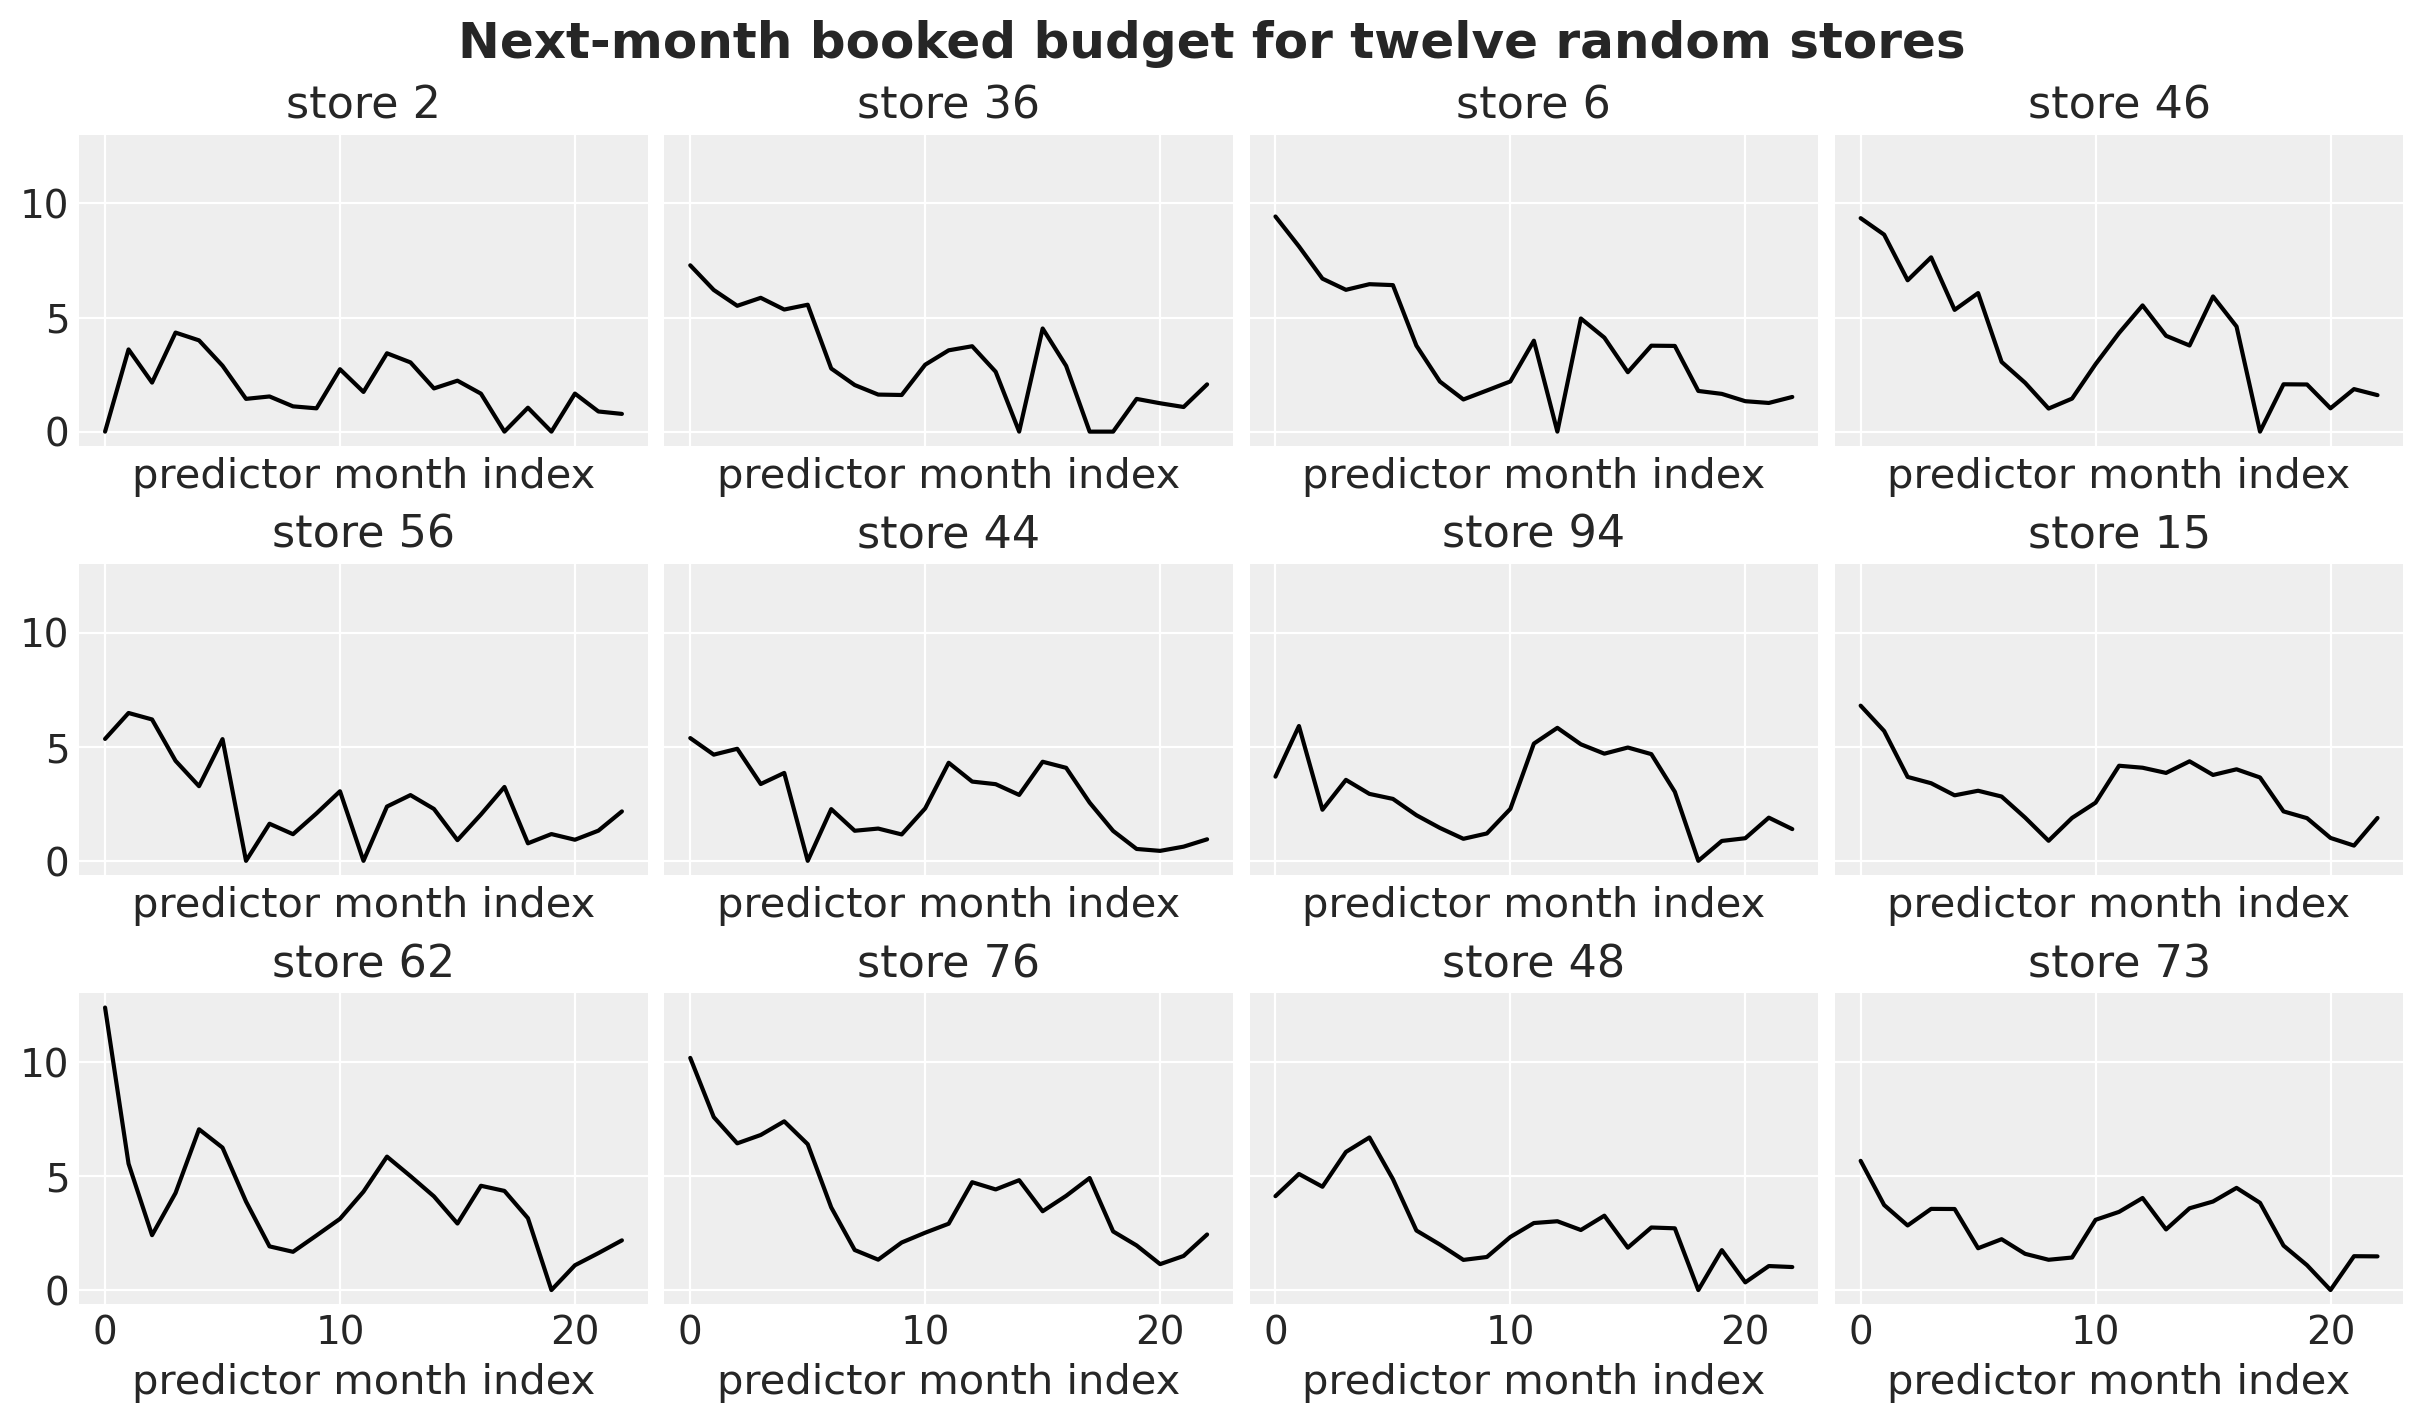

In [7]:
n_random_stores = 12

sample_ids = rng.choice(
    panel["store_id"].unique().to_numpy(), size=n_random_stores, replace=False
)

fig, axes = plt.subplots(
    nrows=3,
    ncols=4,
    figsize=(12, 7),
    sharex=True,
    sharey=True,
    layout="constrained",
)

for ax, sid in zip(axes.flat, sample_ids, strict=True):
    sub = panel.filter(pl.col("store_id").eq(pl.lit(sid))).sort("predictor_month_idx")
    ax.plot(
        sub["predictor_month_idx"].to_numpy(),
        sub["budget_next"].to_numpy(),
        color="black",
    )
    ax.set(title=f"store {sid}", xlabel="predictor month index")
fig.suptitle(
    "Next-month booked budget for twelve random stores", fontsize=18, fontweight="bold"
);

We now plot the histograms for next month's budget and ROAS.

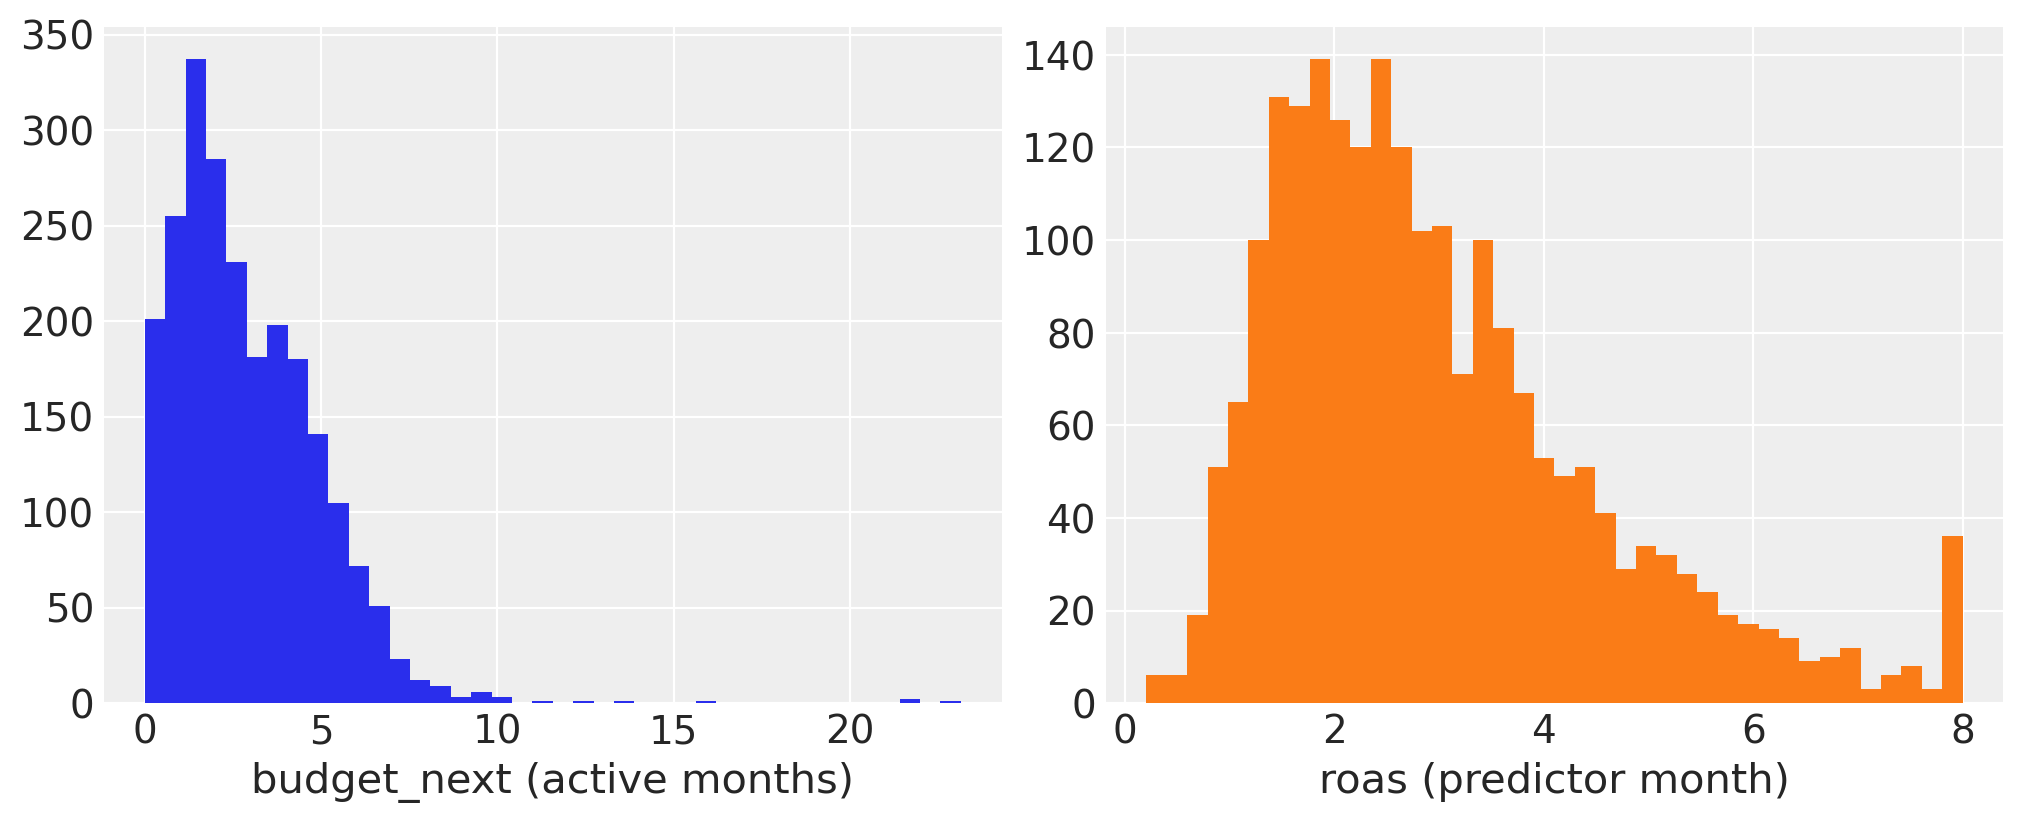

In [24]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 4), layout="constrained")
axes[0].hist(panel["budget_next"].to_numpy(), bins=40, color="C0")
axes[0].set(xlabel="budget_next (active months)")
axes[1].hist(
    panel.filter(pl.col("roas").is_not_nan())["roas"].to_numpy(), bins=40, color="C1"
)
axes[1].set(xlabel="roas (predictor month)");

Let's visualize their relationship via a scatter plot.

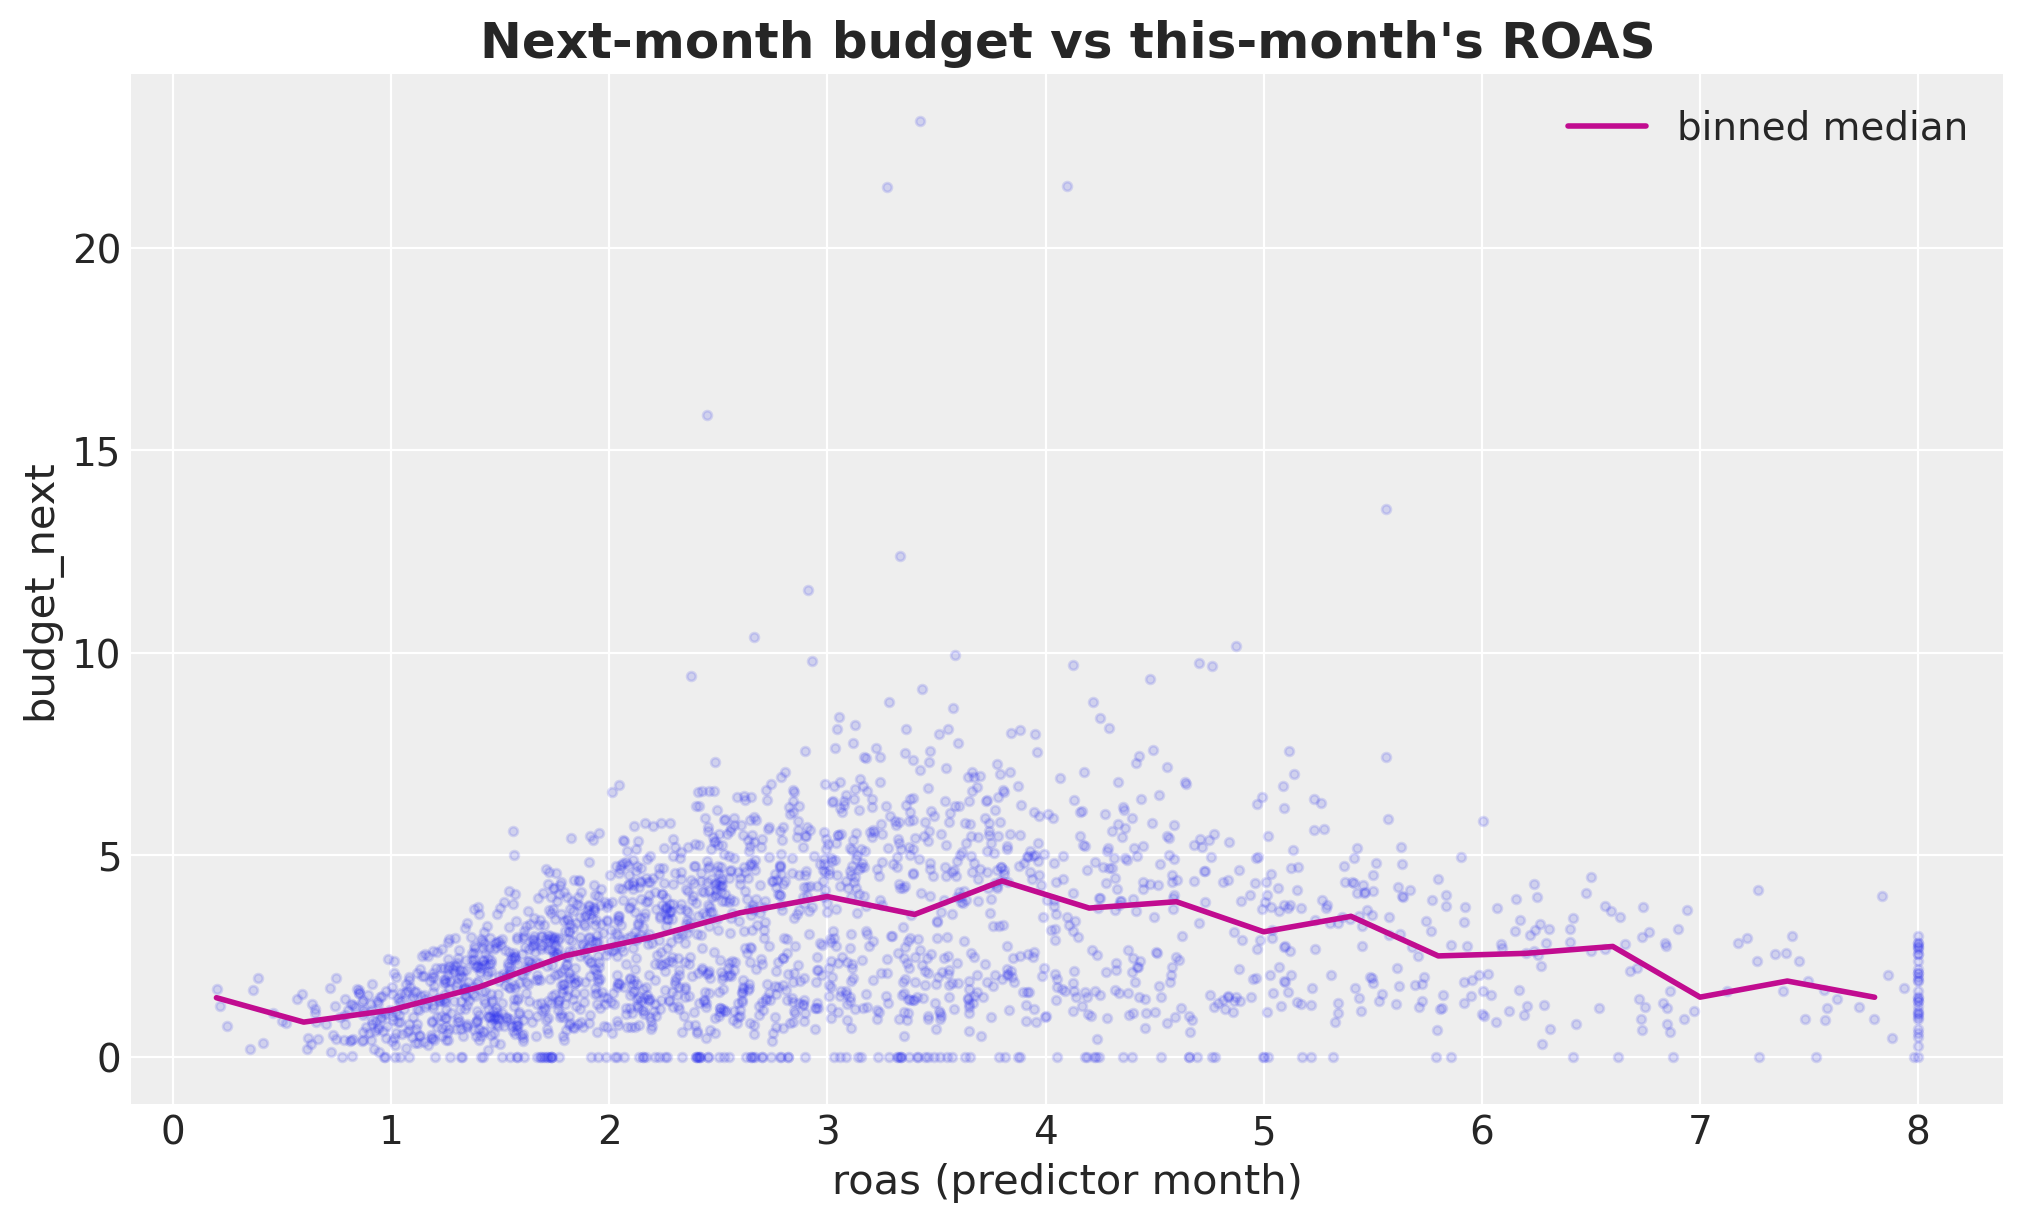

In [27]:
roas_bins = np.linspace(0, 8, 21)
bin_centers = 0.5 * (roas_bins[:-1] + roas_bins[1:])
scatter_df = panel.filter(pl.col("roas").is_not_nan())
roas_arr = scatter_df["roas"].to_numpy()
budget_arr = scatter_df["budget_next"].to_numpy()
bin_idx = np.digitize(roas_arr, roas_bins) - 1
bin_idx = np.clip(bin_idx, 0, len(bin_centers) - 1)
medians = np.array(
    [
        np.median(budget_arr[bin_idx == i]) if np.any(bin_idx == i) else np.nan
        for i in range(len(bin_centers))
    ]
)

fig, ax = plt.subplots()
ax.scatter(roas_arr, budget_arr, alpha=0.15, s=10)
ax.plot(bin_centers, medians, color="C3", linewidth=2, label="binned median")
ax.legend()
ax.set(
    xlabel="roas (predictor month)",
    ylabel="budget_next",
)
ax.set_title("Next-month budget vs this-month's ROAS", fontsize=18, fontweight="bold");

The non-linear shape is visible to the eye: budget rises with ROAS, levels off past ROAS≈4. That's the signal we want the model to pick up.

Next, we look into the distribution of the response (next month's budget) by month. Yearly seasonality should be visible by month.

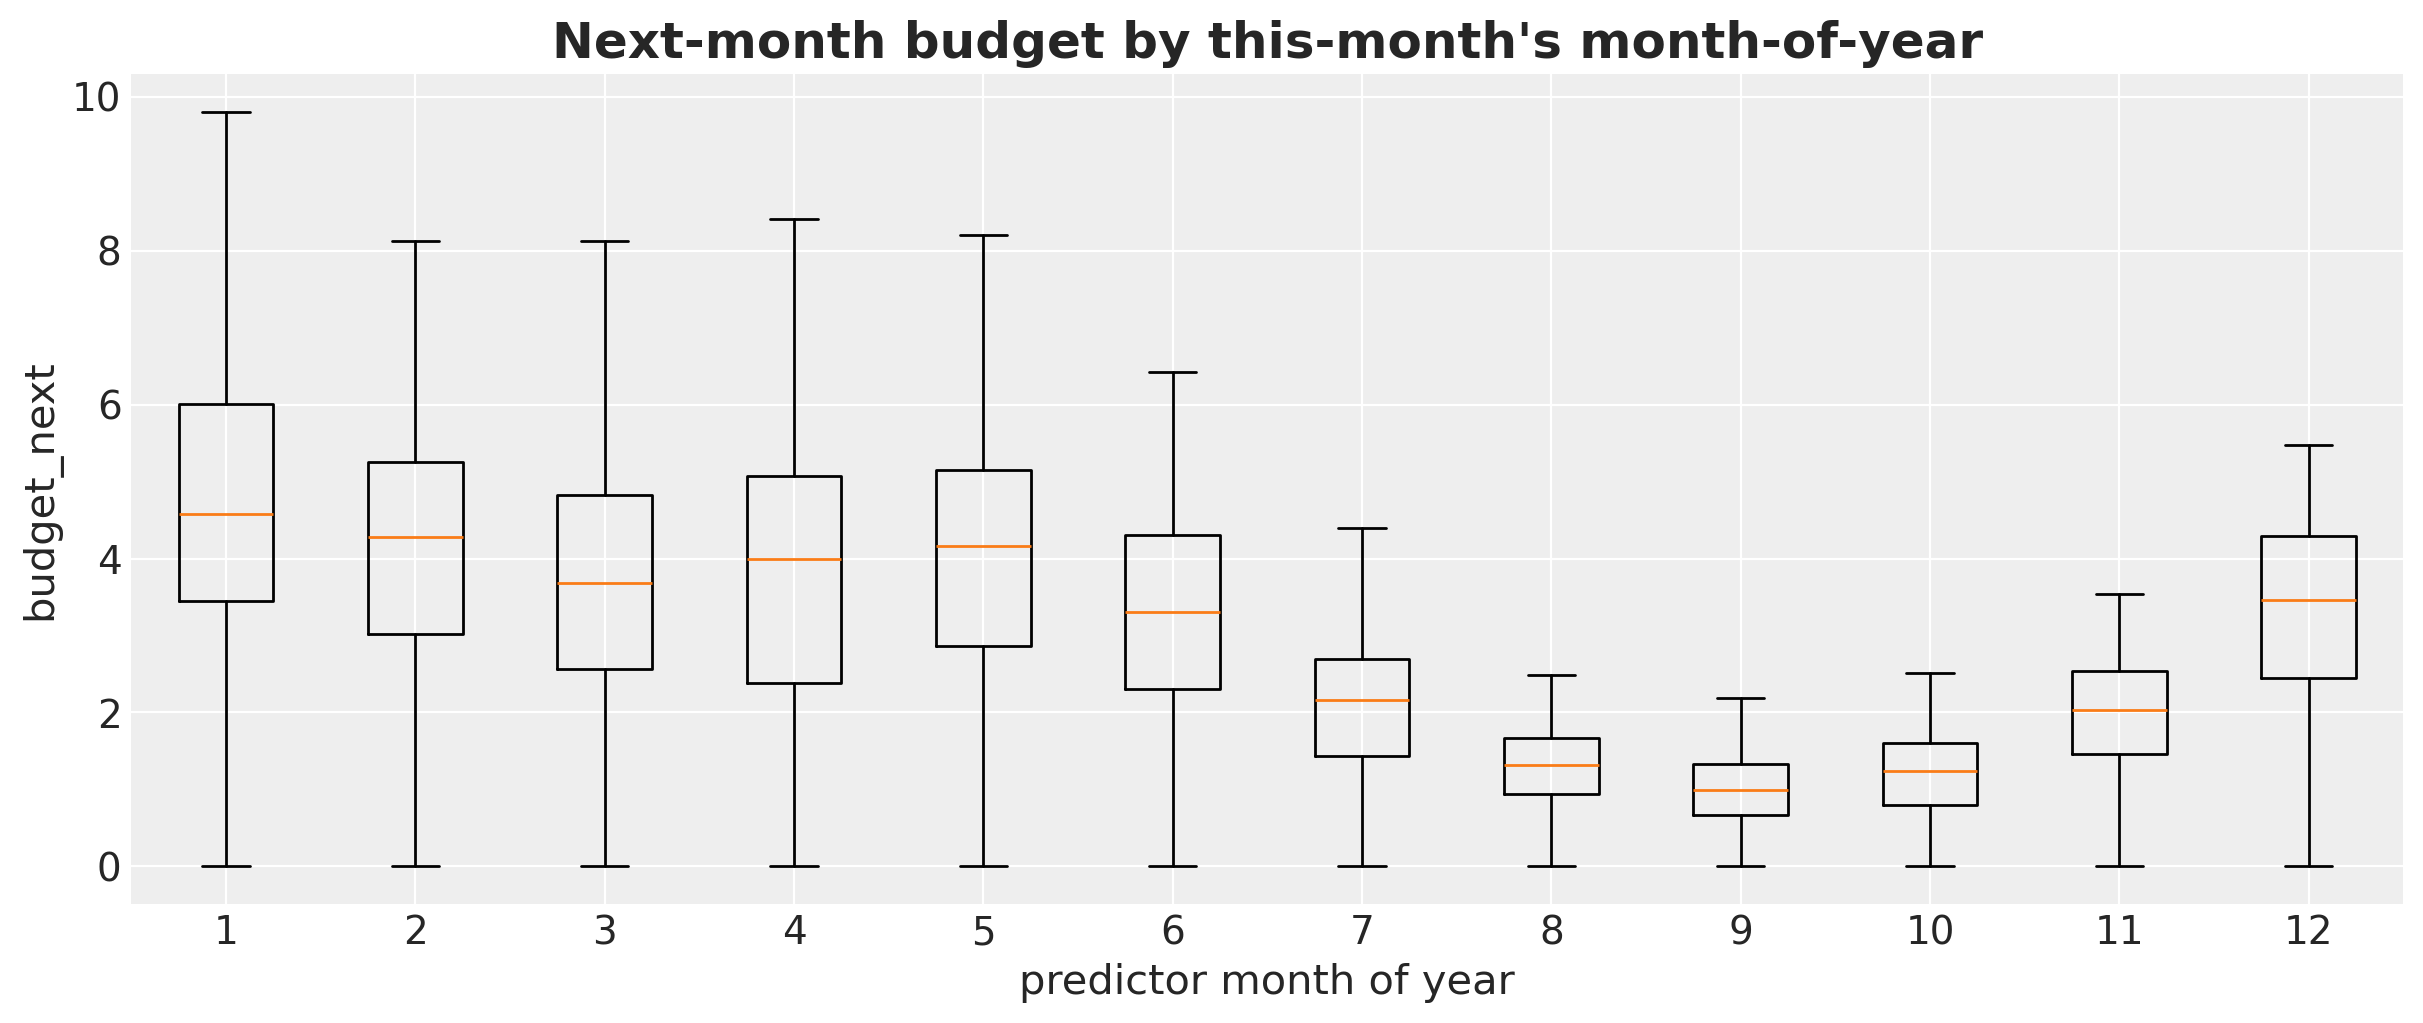

In [10]:
fig, ax = plt.subplots(figsize=(12, 5))
month_groups = [
    panel.filter(pl.col("month_of_year").eq(pl.lit(m)))["budget_next"].to_numpy()
    for m in range(1, 13)
]
ax.boxplot(month_groups, tick_labels=list(range(1, 13)), showfliers=False)
ax.set(
    xlabel="predictor month of year",
    ylabel="budget_next",
)
ax.set_title(
    "Next-month budget by this-month's month-of-year",
    fontsize=18,
    fontweight="bold",
);

Cohort age vs budget: a mild downward drift as stores get older.

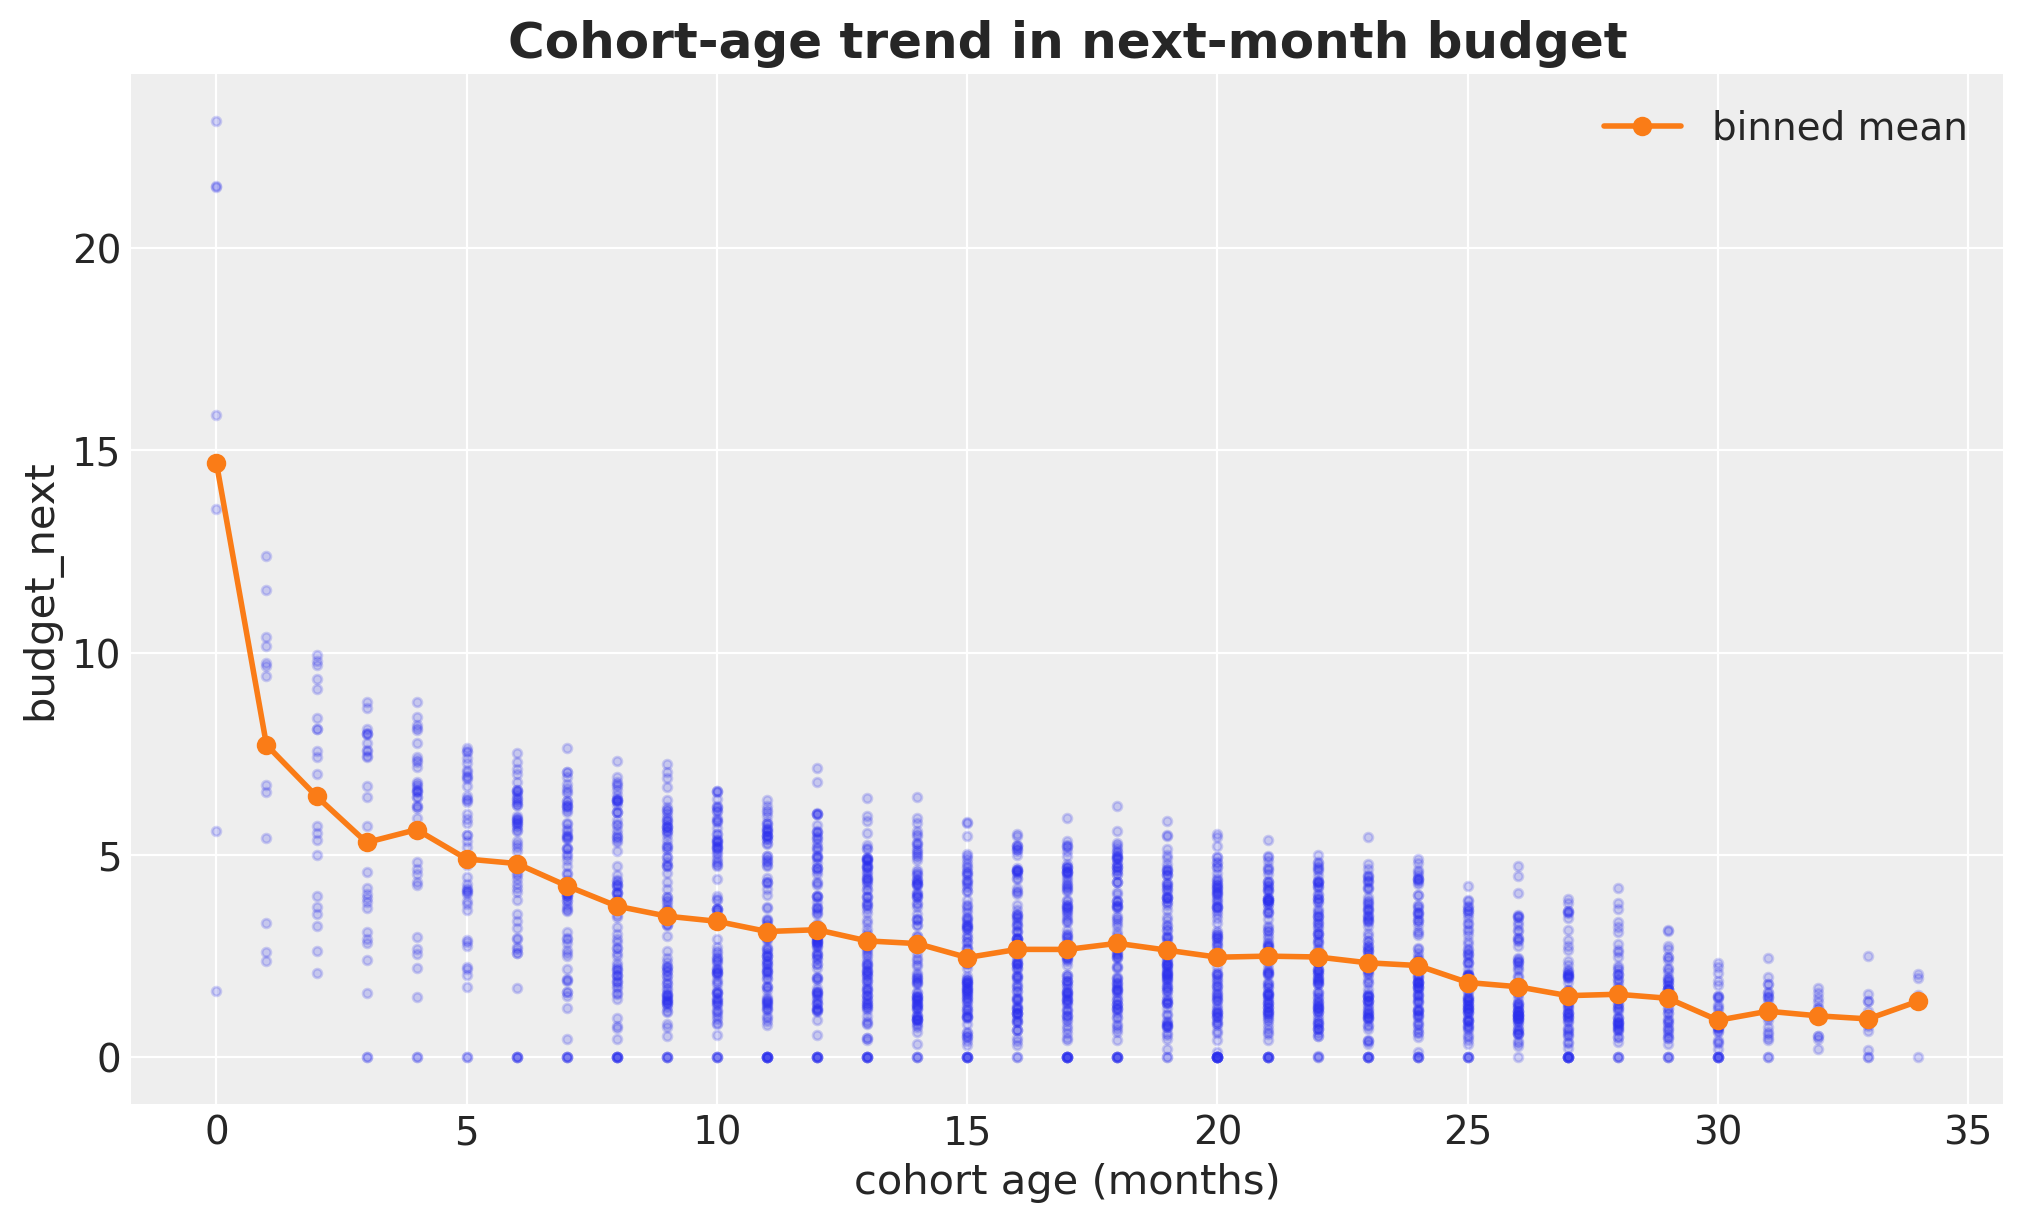

In [11]:
cohort_summary = (
    panel.group_by("cohort_age")
    .agg(pl.col("budget_next").mean().alias("mean_budget"))
    .sort("cohort_age")
)

fig, ax = plt.subplots()
ax.scatter(
    panel["cohort_age"].to_numpy(),
    panel["budget_next"].to_numpy(),
    alpha=0.2,
    s=10,
)
ax.plot(
    cohort_summary["cohort_age"].to_numpy(),
    cohort_summary["mean_budget"].to_numpy(),
    marker="o",
    color="C1",
    linewidth=2,
    label="binned mean",
)
ax.legend()
ax.set(
    xlabel="cohort age (months)",
    ylabel="budget_next",
)
ax.set_title("Cohort-age trend in next-month budget", fontsize=18, fontweight="bold");

## Baseline 1: linear Gaussian (identity link)

We start with the simplest thing that could work: a plain linear regression on all four predictors, Gaussian noise, identity link.

In [15]:
# Dataframe for fitting the Bambi models
model_df = panel.filter(
    pl.col("roas").is_not_nan()
).select(  # Only rows with observed lagged ROAS
    [
        "budget_next",
        "roas",
        "cohort_age",
        "month_of_year",
    ]
)

formula_lm = bmb.Formula("budget_next ~ 1 + cohort_age + C(month_of_year) + roas")

priors_lm = {
    "Intercept": bmb.Prior("Normal", mu=0.0, sigma=2.0),
    "cohort_age": bmb.Prior("Normal", mu=0.0, sigma=1.0),
    "C(month_of_year)": bmb.Prior("ZeroSumNormal", sigma=1.0),
    "roas": bmb.Prior("Normal", mu=0.0, sigma=2.0),
    "sigma": bmb.Prior("HalfNormal", sigma=5.0),
}

model_lm = bmb.Model(
    formula=formula_lm,
    data=model_df.to_pandas(),
    family="gaussian",
    link="identity",
    priors=priors_lm,
)
model_lm.build()

model_lm

       Formula: budget_next ~ 1 + cohort_age + C(month_of_year) + roas
        Family: gaussian
          Link: mu = identity
  Observations: 2169
        Priors: 
    target = mu
        Common-level effects
            Intercept ~ Normal(mu: 0.0, sigma: 2.0)
            cohort_age ~ Normal(mu: 0.0, sigma: 1.0)
            C(month_of_year) ~ ZeroSumNormal(sigma: 1.0)
            roas ~ Normal(mu: 0.0, sigma: 2.0)
        
        Auxiliary parameters
            sigma ~ HalfNormal(sigma: 5.0)

### Prior predictive

Let's start by looking at the prior predictive distribution.

Sampling: [C(month_of_year), Intercept, budget_next, cohort_age, roas, sigma]


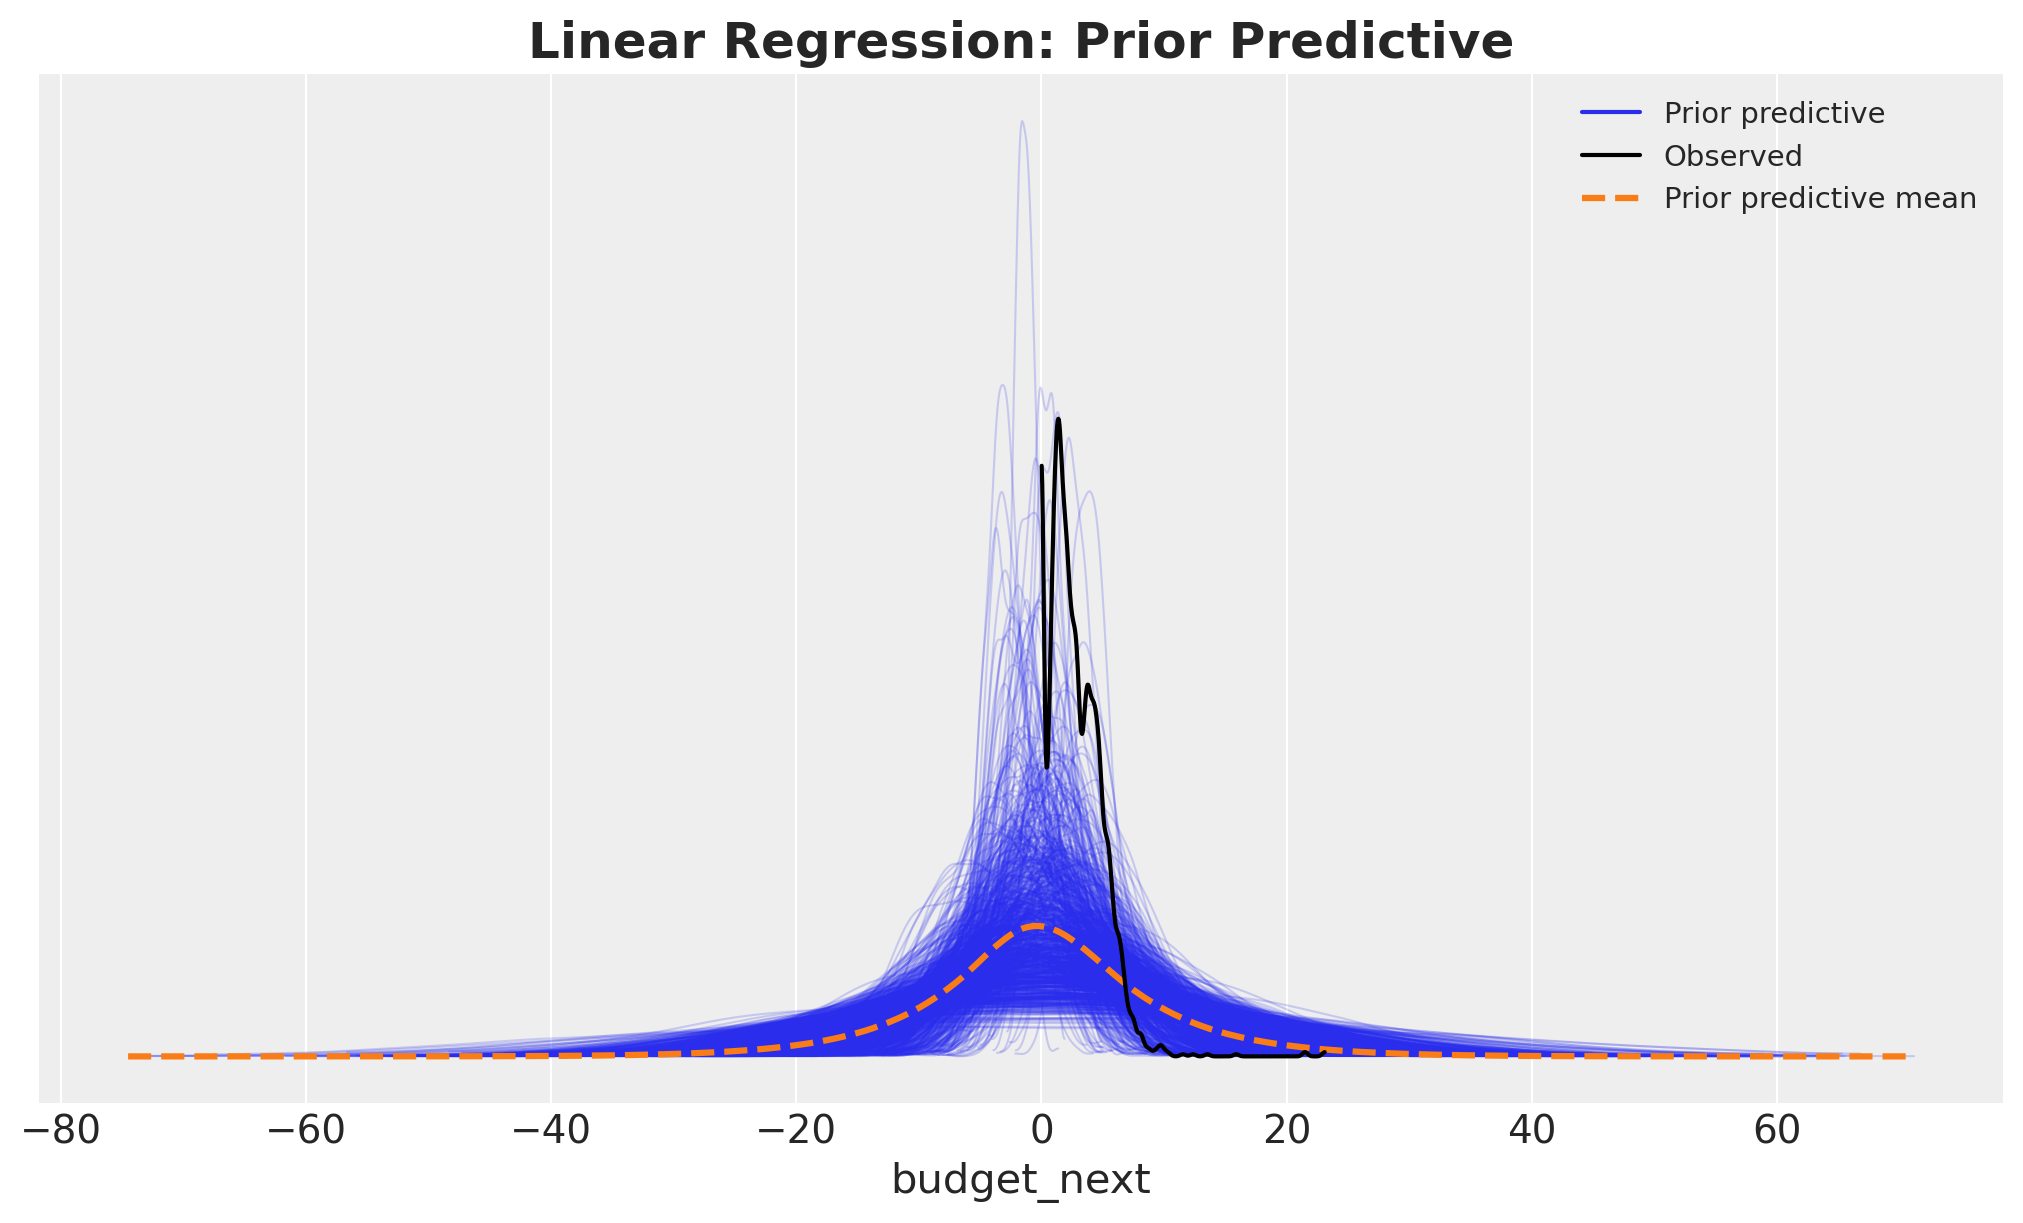

In [16]:
idata_prior_lm = model_lm.prior_predictive(draws=1_000, random_seed=rng)

fig, ax = plt.subplots()
az.plot_ppc(idata_prior_lm, group="prior", observed=True, ax=ax)
ax.set_title("Linear Regression: Prior Predictive", fontsize=18, fontweight="bold");

Overall, the prior predictive looks reasonable. Still, we see a conceptial problem with our model: we are allowing negative values for `budget_next`, which we know is non-negative. We will tackle this issue in the next model iteration below.

### Model Fit

We now fir the model to the data.

In [17]:
idata_lm = model_lm.fit(
    draws=1_000,
    tune=1_000,
    chains=4,
    target_accept=0.8,
    inference_method="numpyro",
    random_seed=rng,
    idata_kwargs={"log_likelihood": True},
)

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

### Diagnostics

Let's look now at the model diagnostics.

In [18]:
# Number of divergences
idata_lm["sample_stats"]["diverging"].sum().item()

0

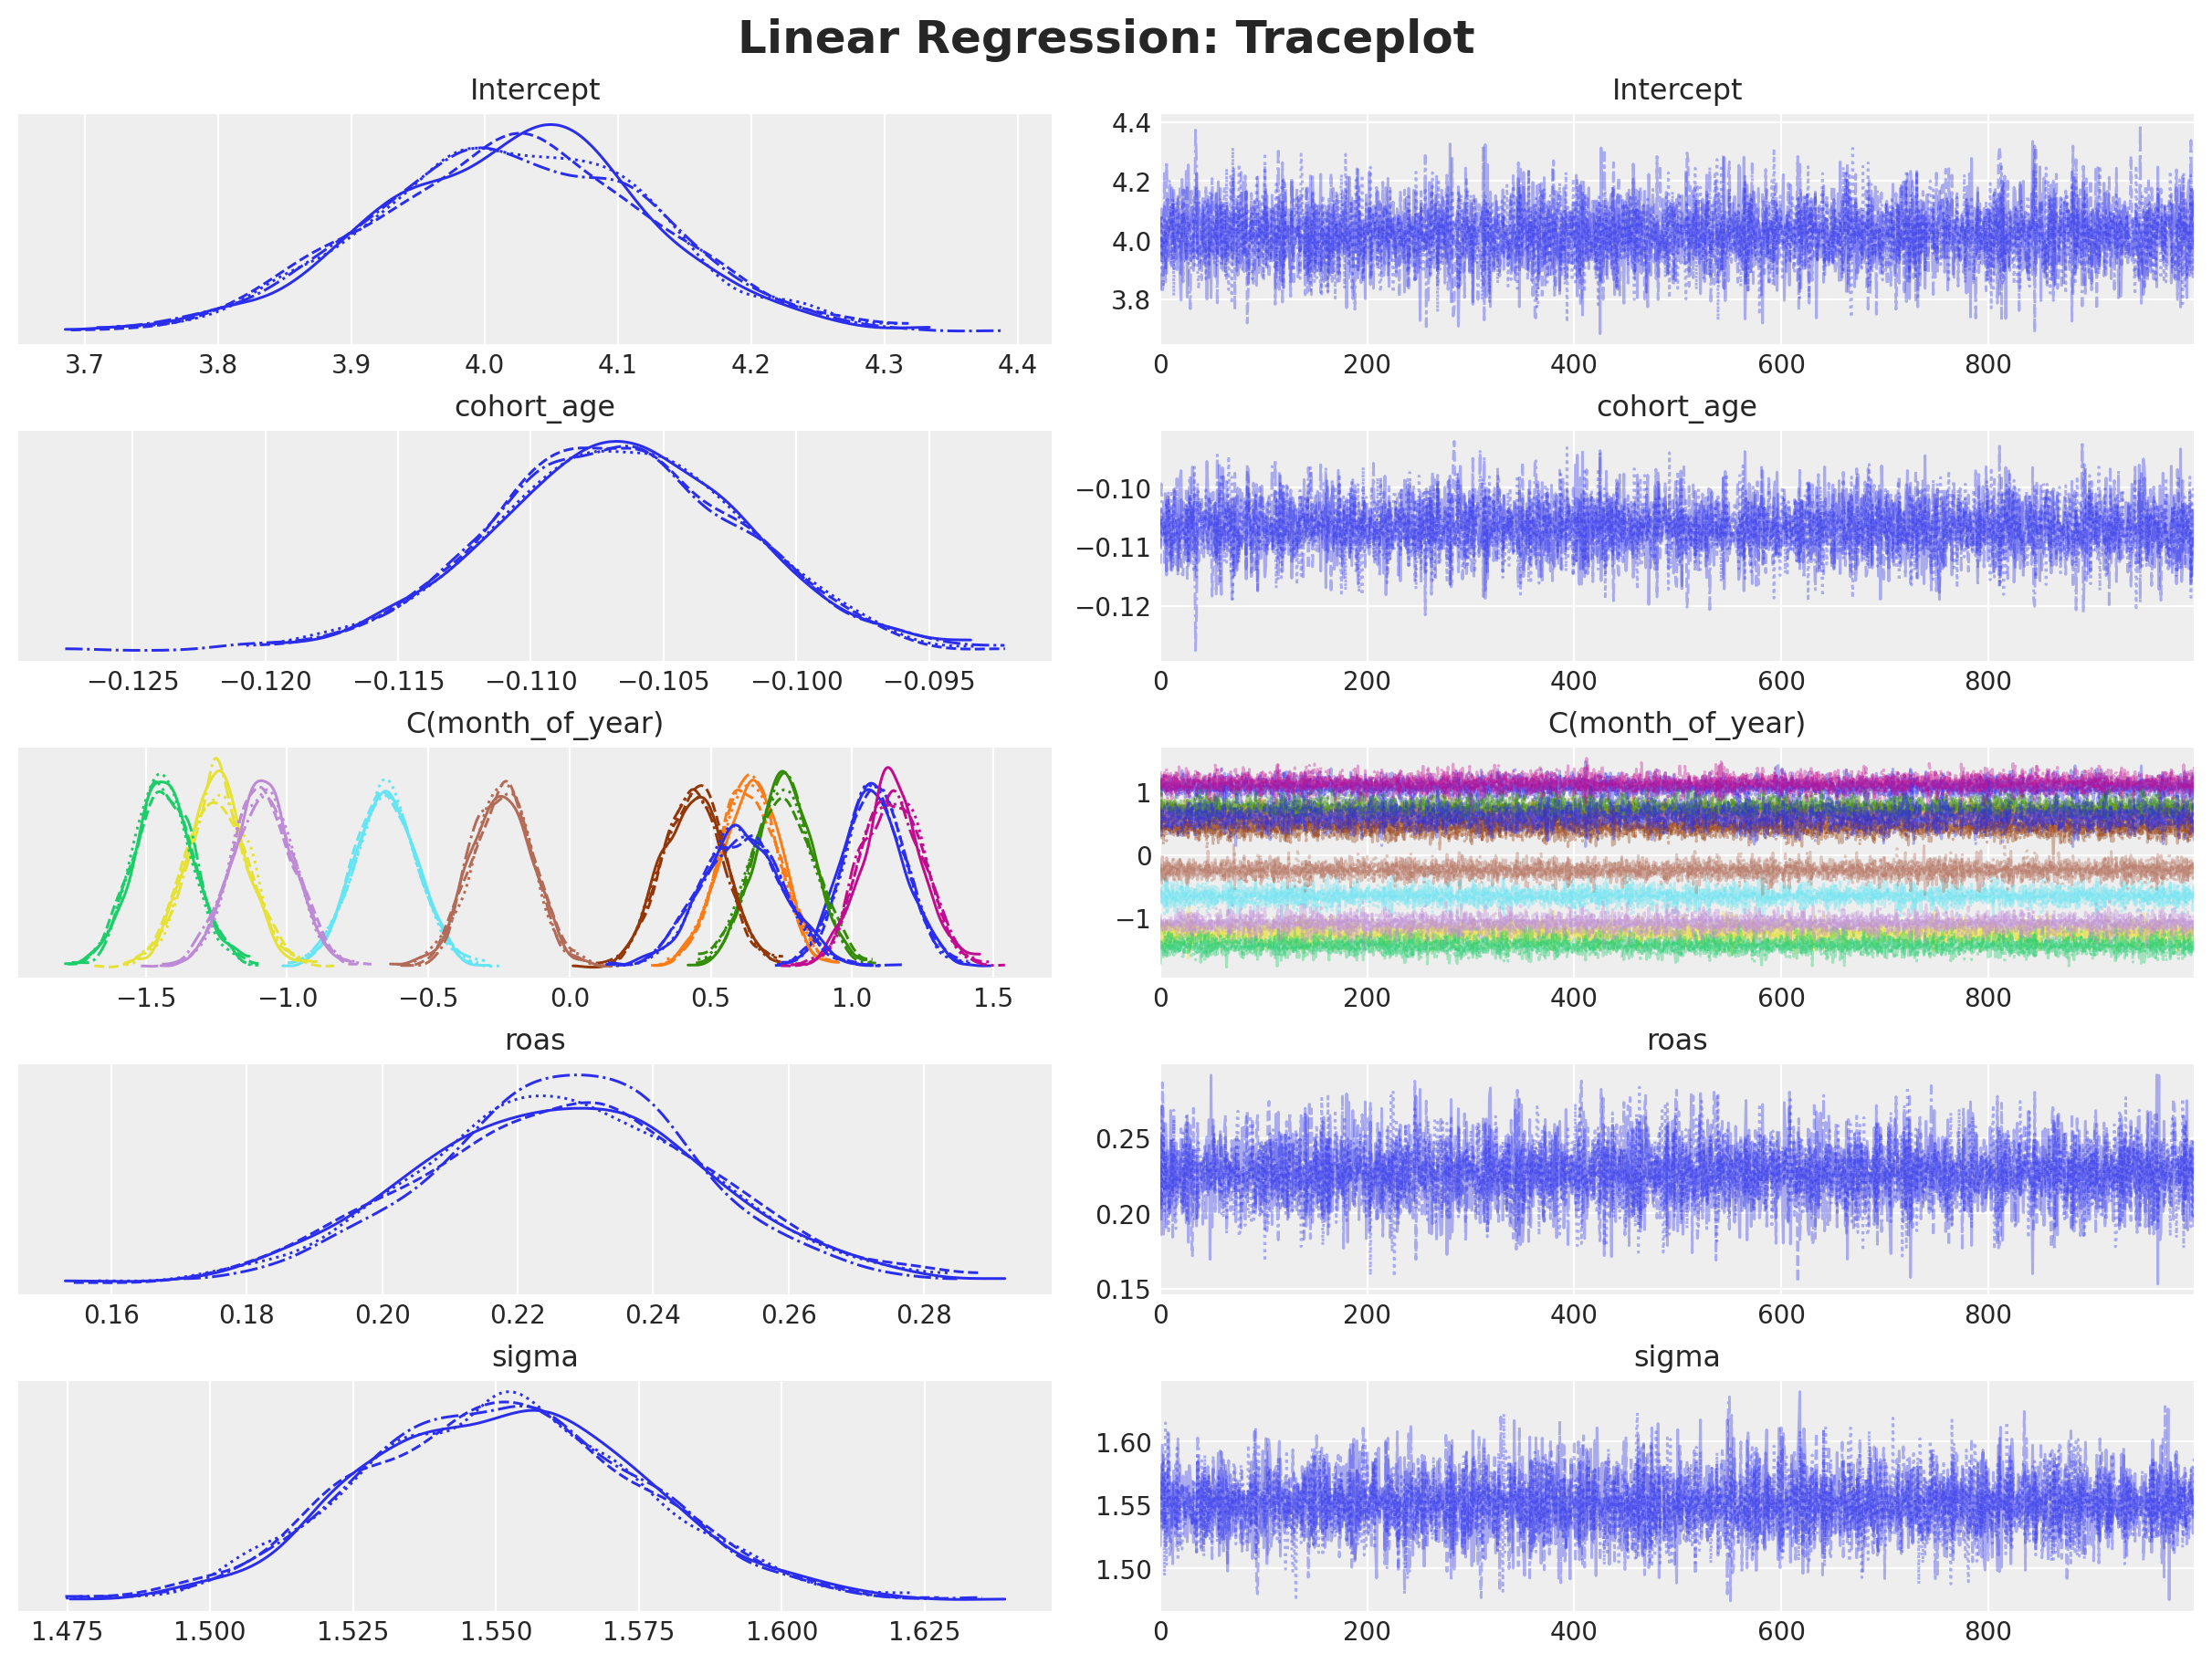

In [19]:
axes = az.plot_trace(
    idata_lm,
    var_names=[
        "Intercept",
        "cohort_age",
        "C(month_of_year)",
        "roas",
        "sigma",
    ],
    compact=True,
    figsize=(12, 9),
    backend_kwargs={"layout": "constrained"},
)

plt.gcf().suptitle("Linear Regression: Traceplot", fontsize=18, fontweight="bold");

We do not see any divergences and the traceplots look good. Let's look now at the posterior predictive distribution.

In [ ]:
model_lm.predict(idata_lm, kind="response", inplace=True)

fig, ax = plt.subplots()
az.plot_ppc(idata_lm, num_pp_samples=1_000, ax=ax)
ax.set_title("Linear Regression: Posterior Predictive", fontsize=18, fontweight="bold");

Besides the negative values, the posterior predictive distribution shows another issue: we are not capturing the large amount of zeros. We will also tackle this issue in the next model iteration below.

### ROAS Effect on Next Month's Budget

We are now interested in inspecting the inferred relationship between ROAS and next month's budget from this baseline linear model. In this case, because the model is linear and there is no link function, we can simply extract this information from the regression coefficient. 

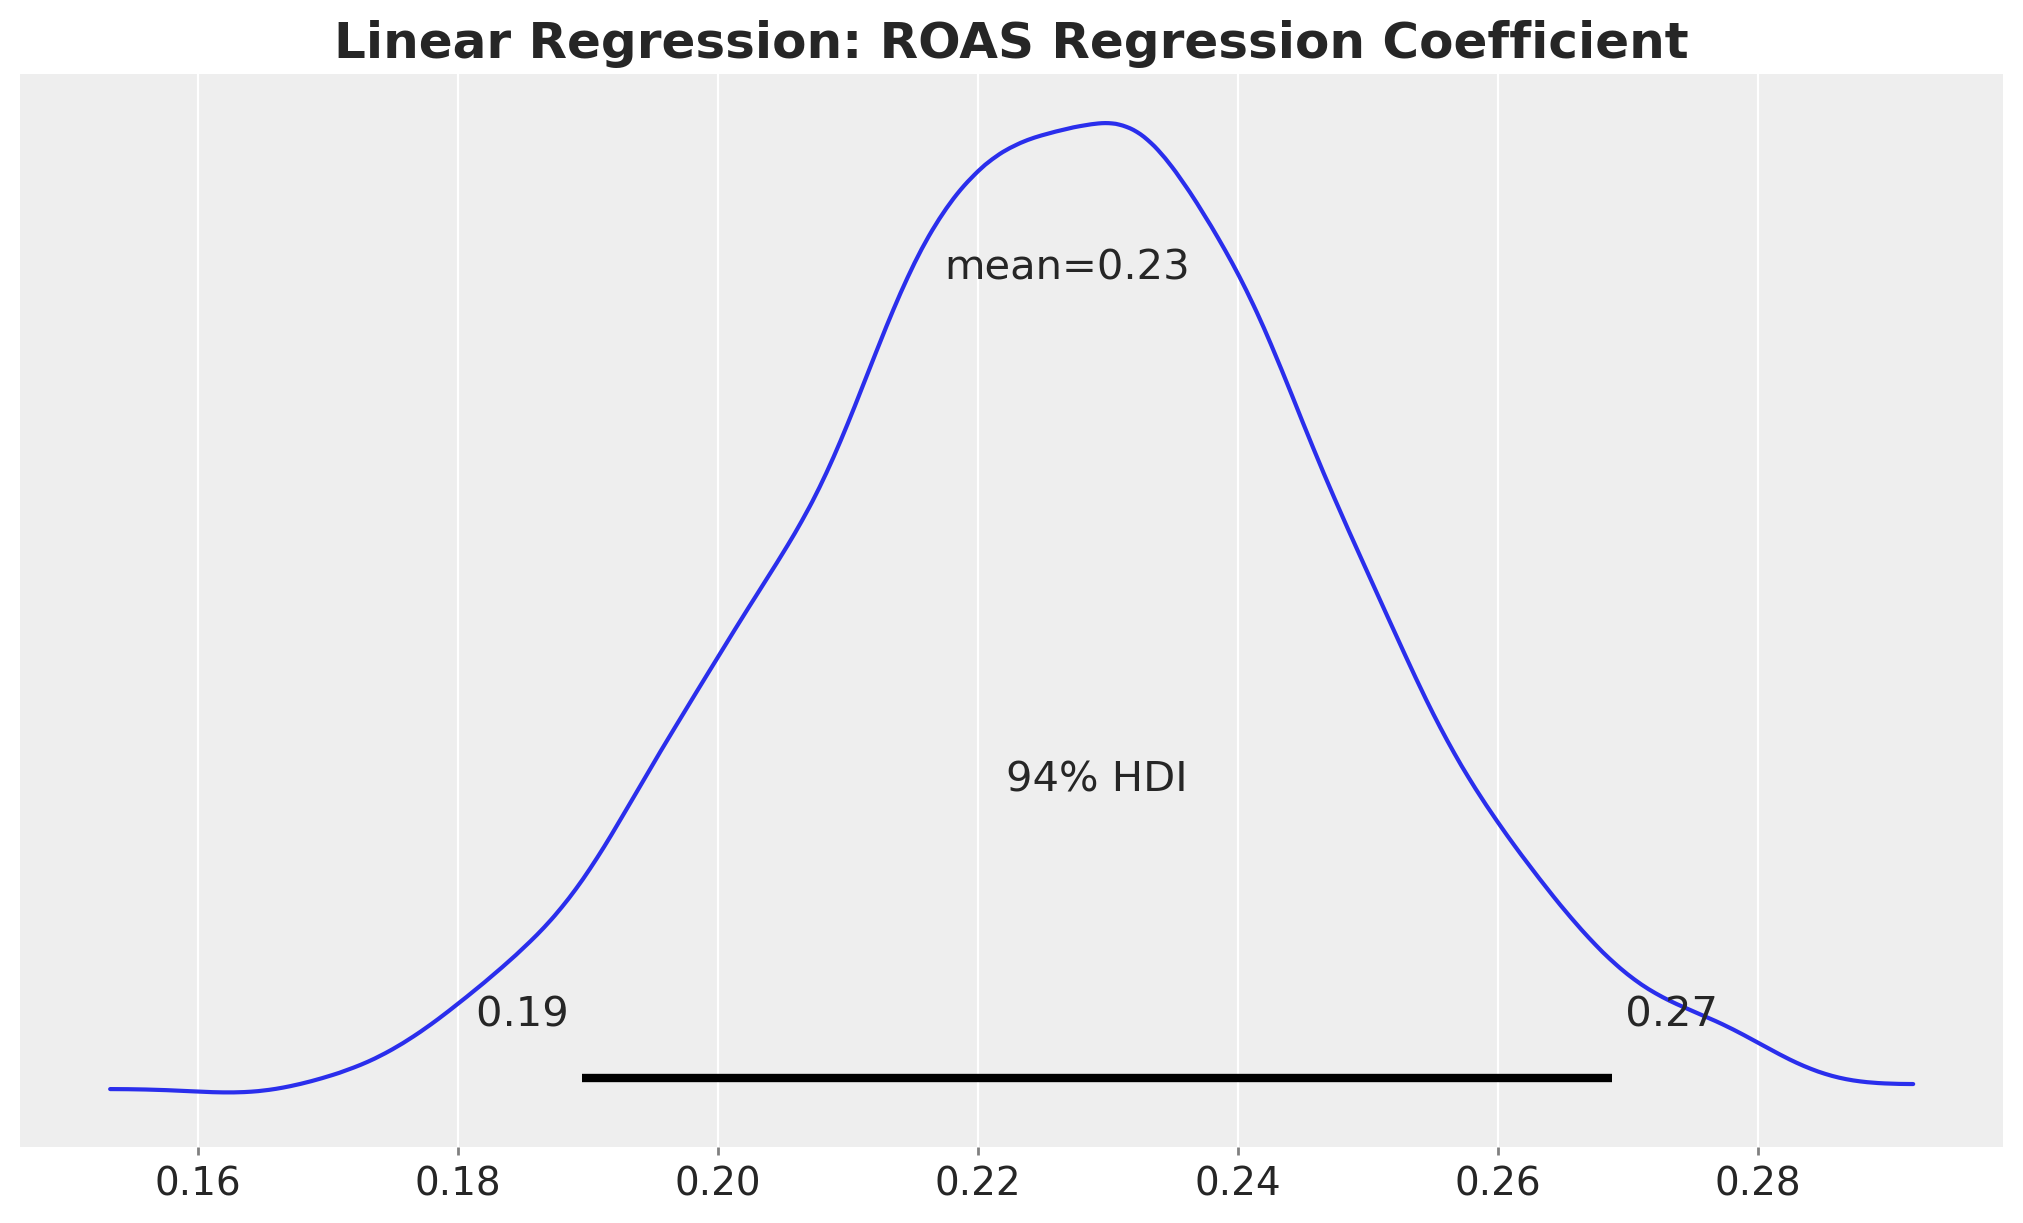

In [ ]:
fig, ax = plt.subplots()
az.plot_posterior(idata_lm, var_names="roas", ax=ax)
ax.set_title(
    "Linear Regression: ROAS Regression Coefficient", fontsize=18, fontweight="bold"
);

We wan interpret this as follows: an increase of one unit in ROAS is associated with an increase of $0.23$ units in next month's budget, while holding the rest of the features constant. Note that, by design, this holds true regardless of the ROAS level. This goes against what we have seen in the exploratory data analysis above. 

An alternative way to communicate this result is to study the posterior over a grid of values $\mathbb{E}[Y \mid \text{grid}]$. The idea is to explicitly show how varying ROAS affects the response. This method is described in detail in the book ["Model to Meaning: How to Interpret Statistical Models with marginaleffects for R and Python "](https://marginaleffects.com/).

We need to start by defining individual grids for each feature:

In [30]:
roas_grid = np.linspace(0.0, panel["roas"].max(), 20)
month_of_year_grid = np.arange(1, 13)
cohort_age_grid = np.arange(panel["cohort_age"].min(), panel["cohort_age"].max(), 1)

To generate predictions for this model we need to specify **all values** for the input features. In this case: `roas`, `cohort_age` and `month_of_year`. This is where the thinking happens! Which type of information we want to convey? This question should define the grid structure. For example, to simply showcase how next month's budget varies with ROAS, we can use the `roas_grid` above and the mean values for the other features. We can use the `datagrid` function from the `marginaleffects` package to do this very easily.

In [33]:
roas_datagrid = datagrid(
    roas=roas_grid,
    cohort_age=np.mean(cohort_age_grid).round(),
    month_of_year=np.mean(month_of_year_grid).round(),
    newdata=model_df,
)

roas_datagrid.head()

budget_next,roas,cohort_age,month_of_year
f64,f64,f64,f64
2.891686,0.0,16.0,6.0
2.891686,0.421053,16.0,6.0
2.891686,0.842105,16.0,6.0
2.891686,1.263158,16.0,6.0
2.891686,1.684211,16.0,6.0


Next, we define a helper function to generate posterior samples of the response mean over a grid.

In [ ]:
def predict_mu(model: bmb.Model, idata, grid_pl: pl.DataFrame) -> np.ndarray:
    new_idata = model.predict(
        idata, data=grid_pl, kind="response_params", inplace=False
    )
    return new_idata["posterior"]["mu"]


We are ready to generate predictions over the grid to visualize the relationship between ROAS and next month's budget.

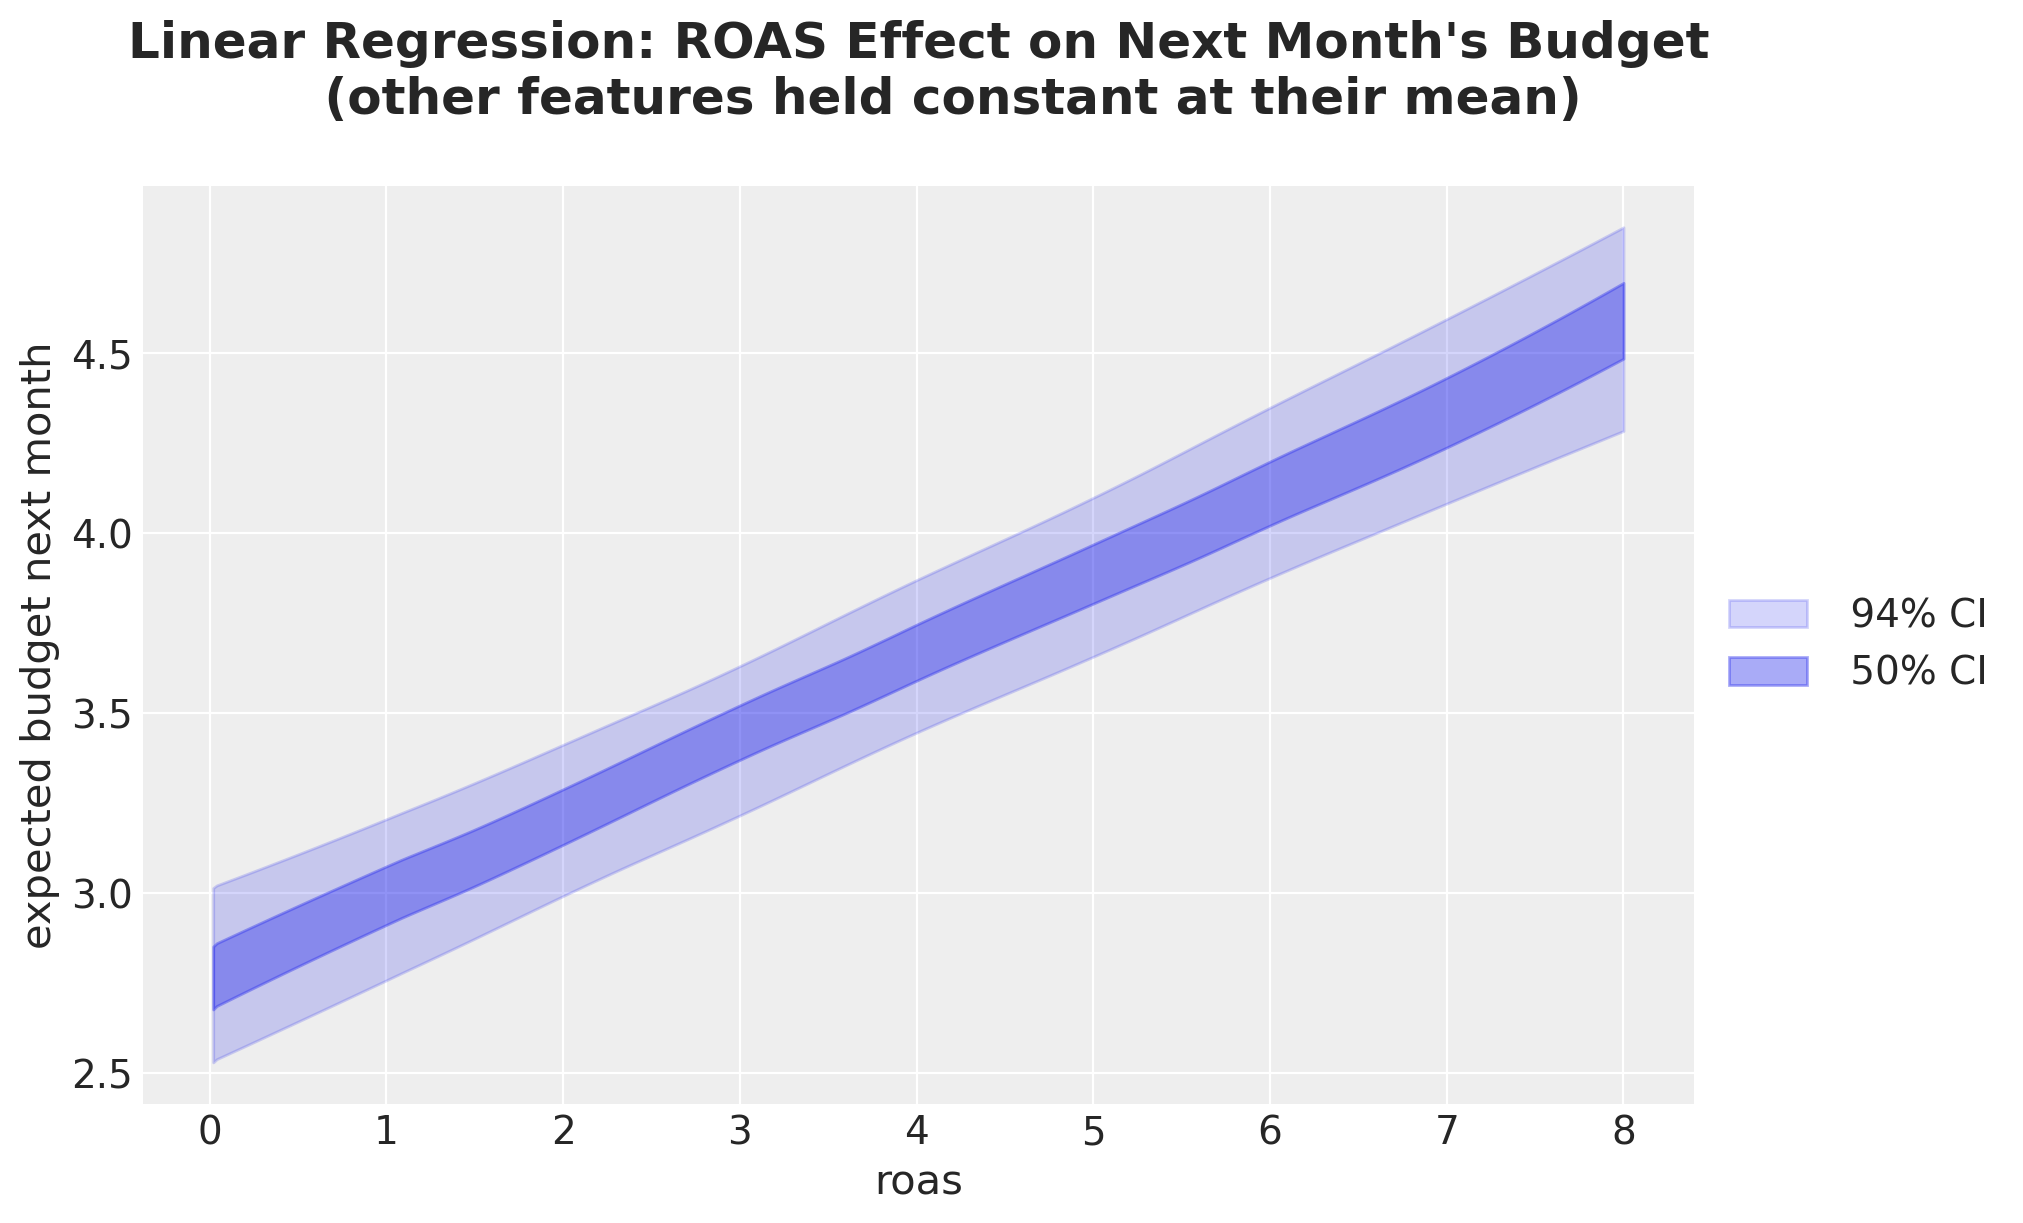

In [ ]:
idata_lm_mu_grid = predict_mu(model_lm, idata_lm, roas_datagrid)

fig, ax = plt.subplots()

for j, hdi_prob in enumerate([0.94, 0.5]):
    az.plot_hdi(
        roas_grid,
        idata_lm_mu_grid,
        hdi_prob=hdi_prob,
        color="C0",
        fill_kwargs={
            "alpha": 0.2 + 0.2 * j,
            "label": f"{hdi_prob: .0%} CI",
        },
        ax=ax,
    )
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))
ax.set(
    xlabel="roas",
    ylabel="expected budget next month",
)
ax.set_title(
    """Linear Regression: ROAS Effect on Next Month's Budget
    (other features held constant at their mean)
    """,
    fontsize=18,
    fontweight="bold",
);

We see that the slope of this posterior predictive line(s) is exactly $0.23$, the same value we got from the regression coefficient. 

We can generalize this idea by considering more granular grids. For instance, we could evaluate the ROAS effect split by cohort age.

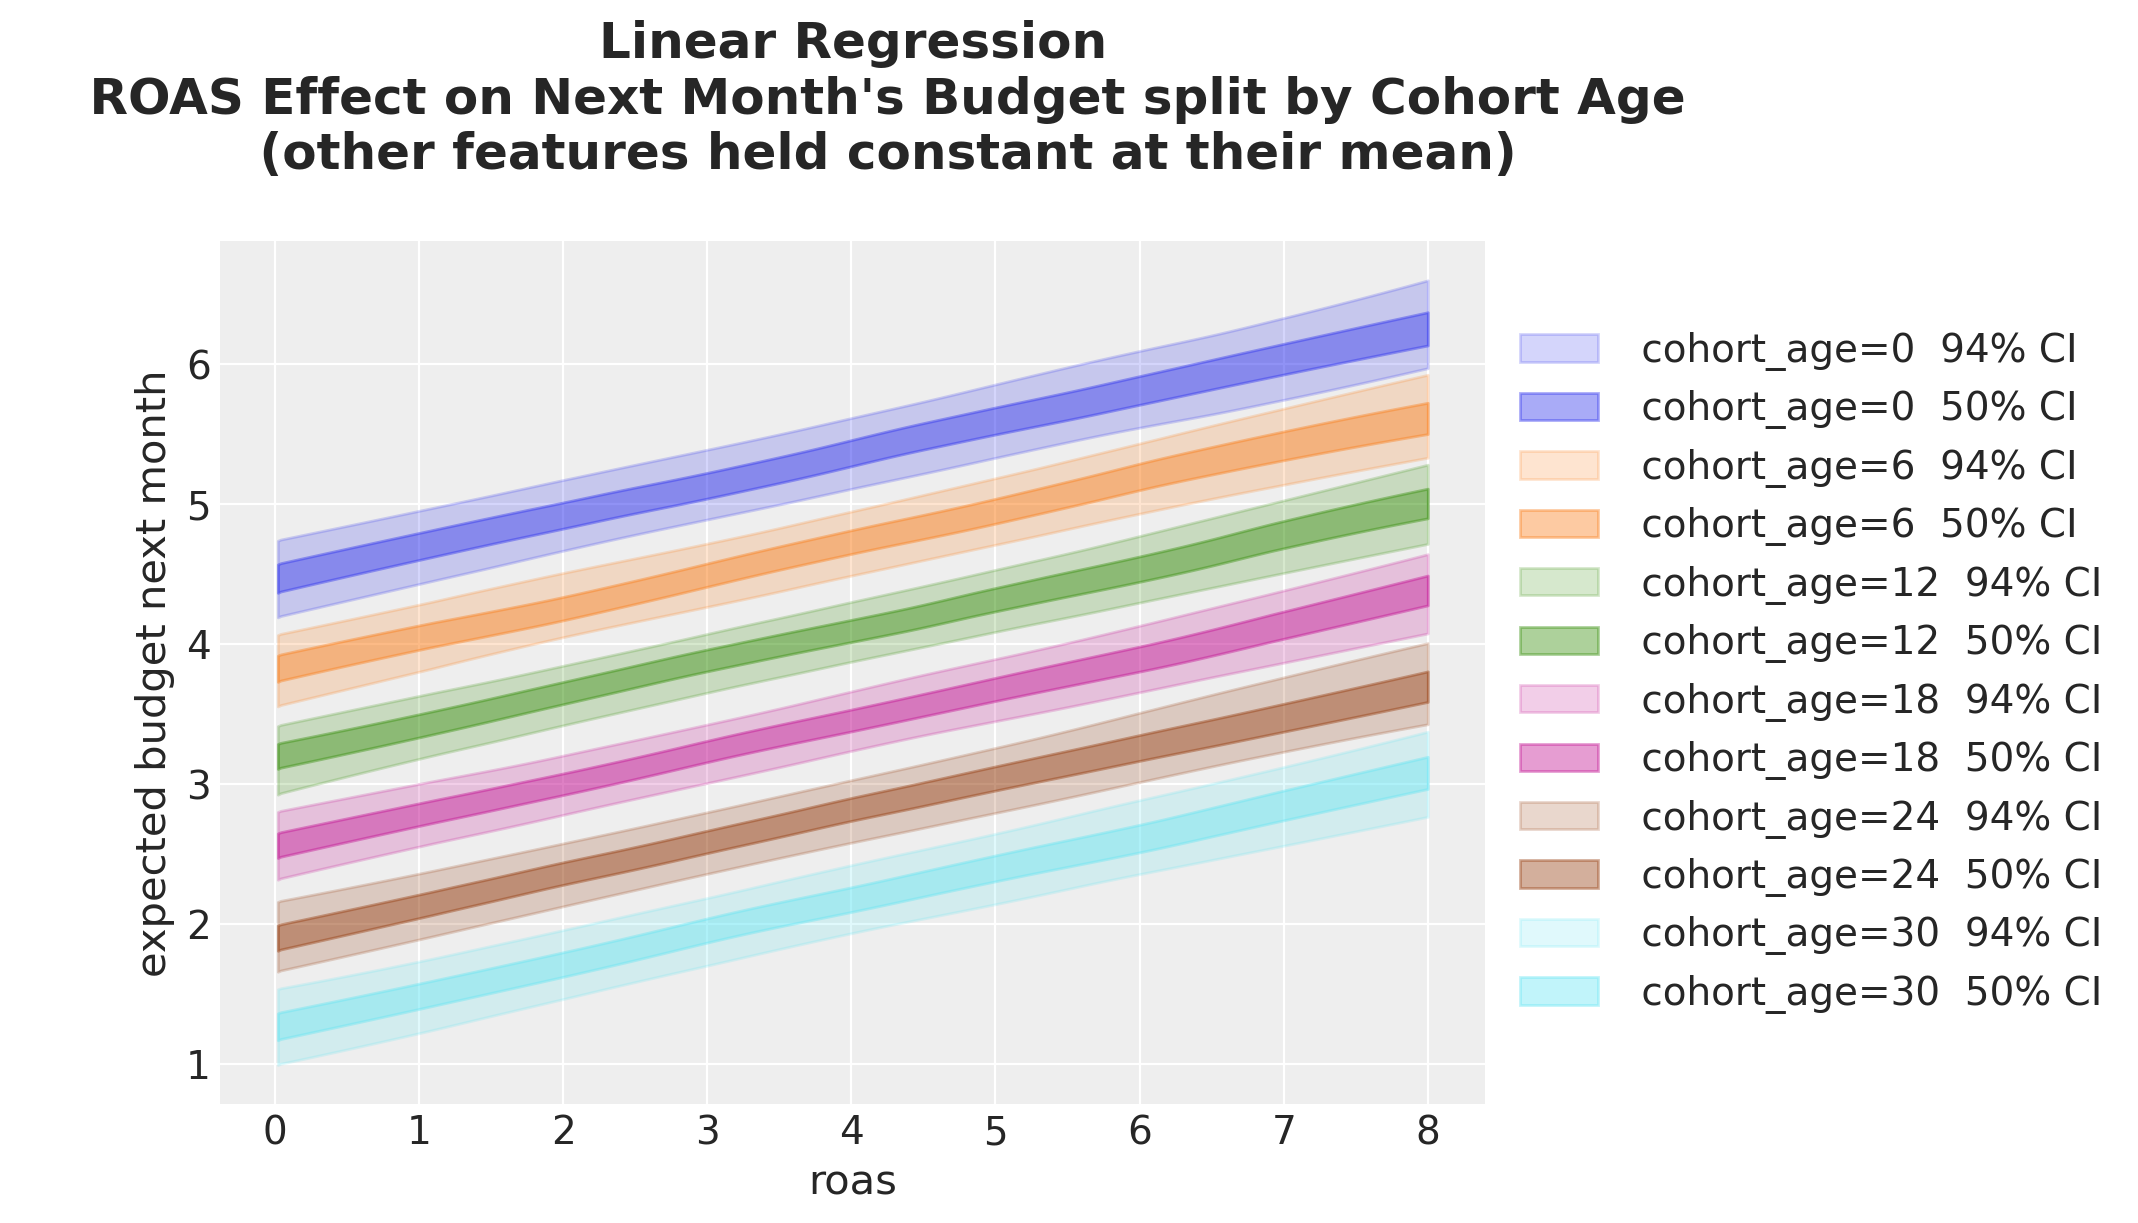

In [ ]:
cohort_roas_grids = {
    x: datagrid(
        roas=roas_grid,
        cohort_age=x,
        month_of_year=np.mean(month_of_year_grid).round(),
        newdata=model_df,
    )
    for x in cohort_age_grid[::6]
}

fig, ax = plt.subplots()

for i, (cohort_age, grid_roas) in enumerate(cohort_roas_grids.items()):
    idata_lm_mu_grid = predict_mu(model_lm, idata_lm, grid_roas)

    for j, hdi_prob in enumerate([0.94, 0.5]):
        az.plot_hdi(
            roas_grid,
            idata_lm_mu_grid,
            hdi_prob=hdi_prob,
            color=f"C{i}",
            fill_kwargs={
                "alpha": 0.2 + 0.2 * j,
                "label": f"cohort_age={cohort_age} {hdi_prob: .0%} CI",
            },
            ax=ax,
        )
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))
ax.set(
    xlabel="roas",
    ylabel="expected budget next month",
)
ax.set_title(
    """Linear Regression
    ROAS Effect on Next Month's Budget split by Cohort Age
    (other features held constant at their mean)
    """,
    fontsize=18,
    fontweight="bold",
);

We see that the ROAS effect, as the slope of the lines, it is the same across all cohort ages. The only difference is the intercept, which varies with cohort age: the older the cohort the lower the estimated budget.

We can do something similar for the month of year.

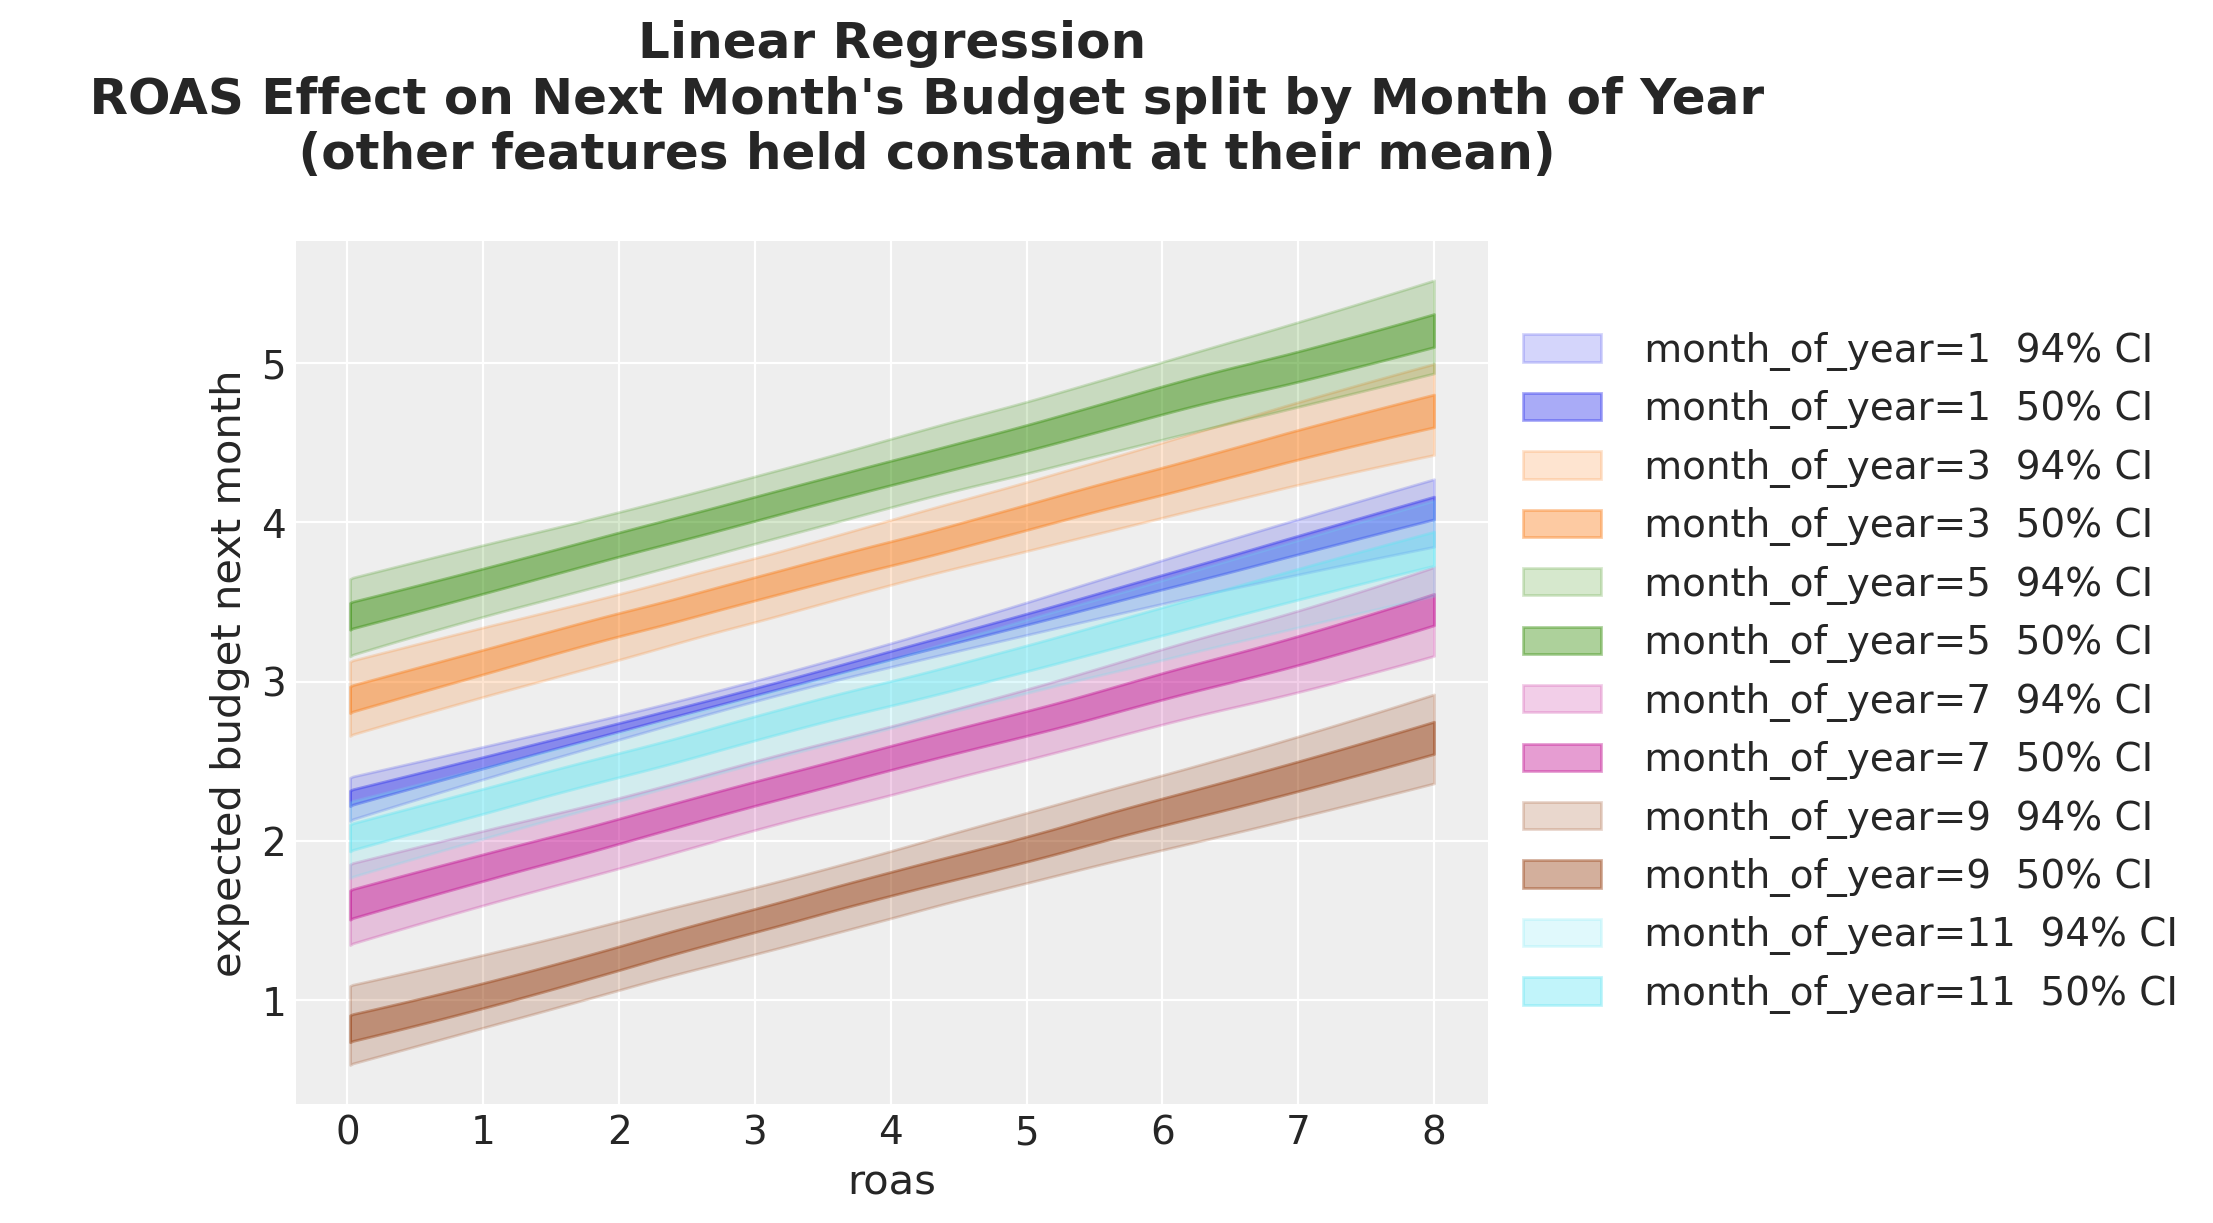

In [ ]:
month_roas_grids = {
    x: datagrid(
        roas=roas_grid,
        cohort_age=np.mean(cohort_age_grid),
        month_of_year=x,
        newdata=model_df,
    )
    for x in month_of_year_grid[::2]
}

fig, ax = plt.subplots()

for i, (month_of_year, grid_roas) in enumerate(month_roas_grids.items()):
    idata_lm_mu_grid = predict_mu(model_lm, idata_lm, grid_roas)

    for j, hdi_prob in enumerate([0.94, 0.5]):
        az.plot_hdi(
            roas_grid,
            idata_lm_mu_grid,
            hdi_prob=hdi_prob,
            color=f"C{i}",
            fill_kwargs={
                "alpha": 0.2 + 0.2 * j,
                "label": f"month_of_year={month_of_year} {hdi_prob: .0%} CI",
            },
            ax=ax,
        )
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))
ax.set(xlabel="roas", ylabel="expected budget next month")
ax.set_title(
    """Linear Regression
    ROAS Effect on Next Month's Budget split by Month of Year
    (other features held constant at their mean)
    """,
    fontsize=18,
    fontweight="bold",
);

We see that the ROAS effect is the same across all months of year. However, the intercept varies with the month of year. This variation in non-linear: the intercept for month $11$ is in between the intercepts for month $1$ and month $9$. 

Besides comparing predictions across grids, we can also compare them via differences or rations. For example, let's compute the difference between the ROAS grid predictions for month $3$ and month $9$.

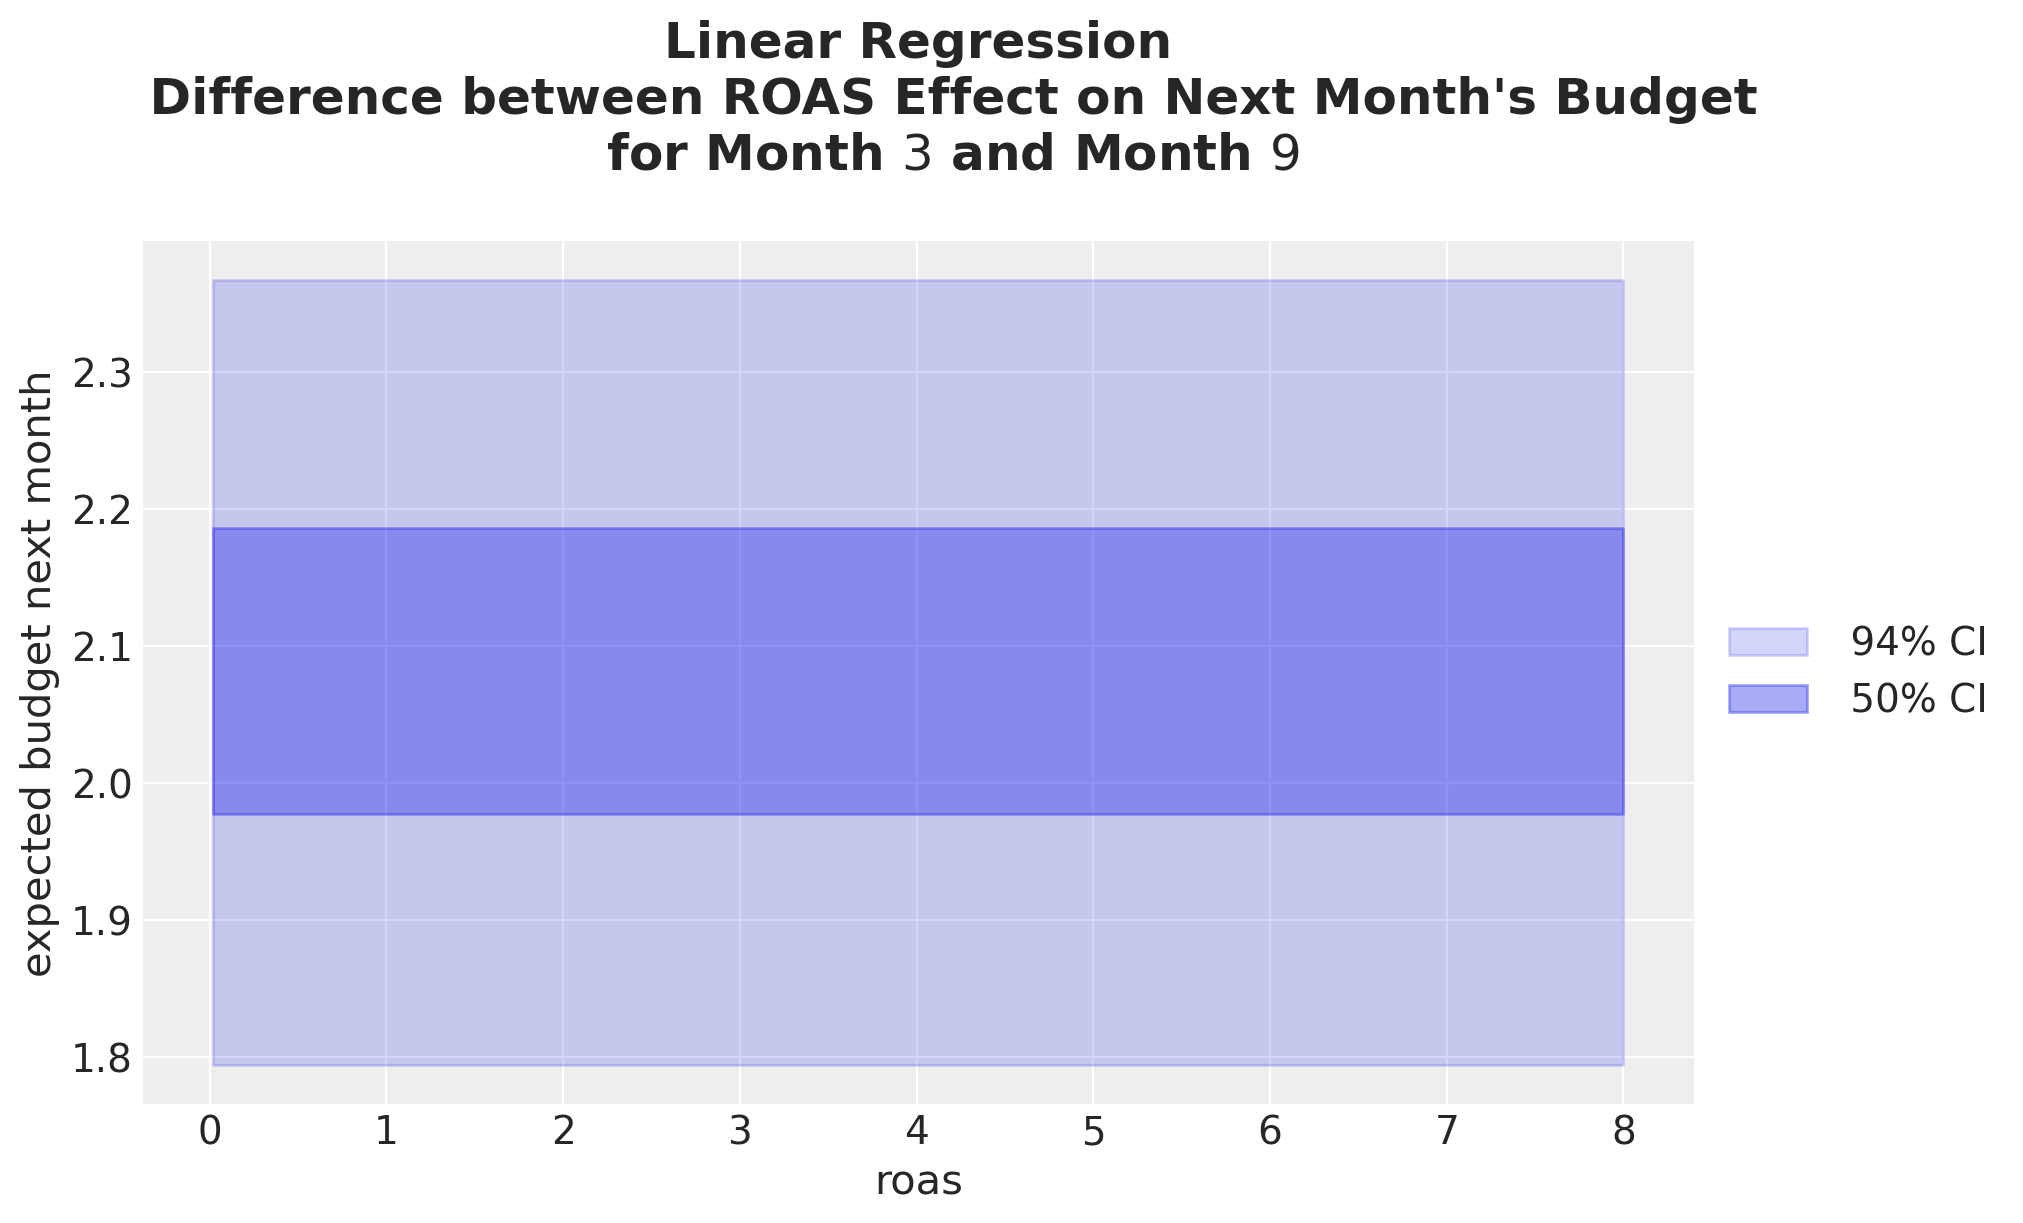

In [62]:
month_of_year_0 = 3
month_of_year_1 = 9

_diff = predict_mu(model_lm, idata_lm, month_roas_grids[month_of_year_0]) - predict_mu(
    model_lm, idata_lm, month_roas_grids[month_of_year_1]
)

fig, ax = plt.subplots()

for j, hdi_prob in enumerate([0.94, 0.5]):
    az.plot_hdi(
        roas_grid,
        _diff,
        hdi_prob=hdi_prob,
        color="C0",
        fill_kwargs={
            "alpha": 0.2 + 0.2 * j,
            "label": f"{hdi_prob: .0%} CI",
        },
        ax=ax,
    )
ax.set(
    xlabel="roas",
    ylabel="expected budget next month",
)
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))
ax.set_title(
    """Linear Regression
    Difference between ROAS Effect on Next Month's Budget
    for Month $3$ and Month $9$
    """,
    fontsize=18,
    fontweight="bold",
);

It is not surprising that the difference is constant across ROAS. This is just because of the linearity of the model. As a matter of fact this contant value(s) is nothing else that the difference between the regression coefficients for month $3$ and month $9$:

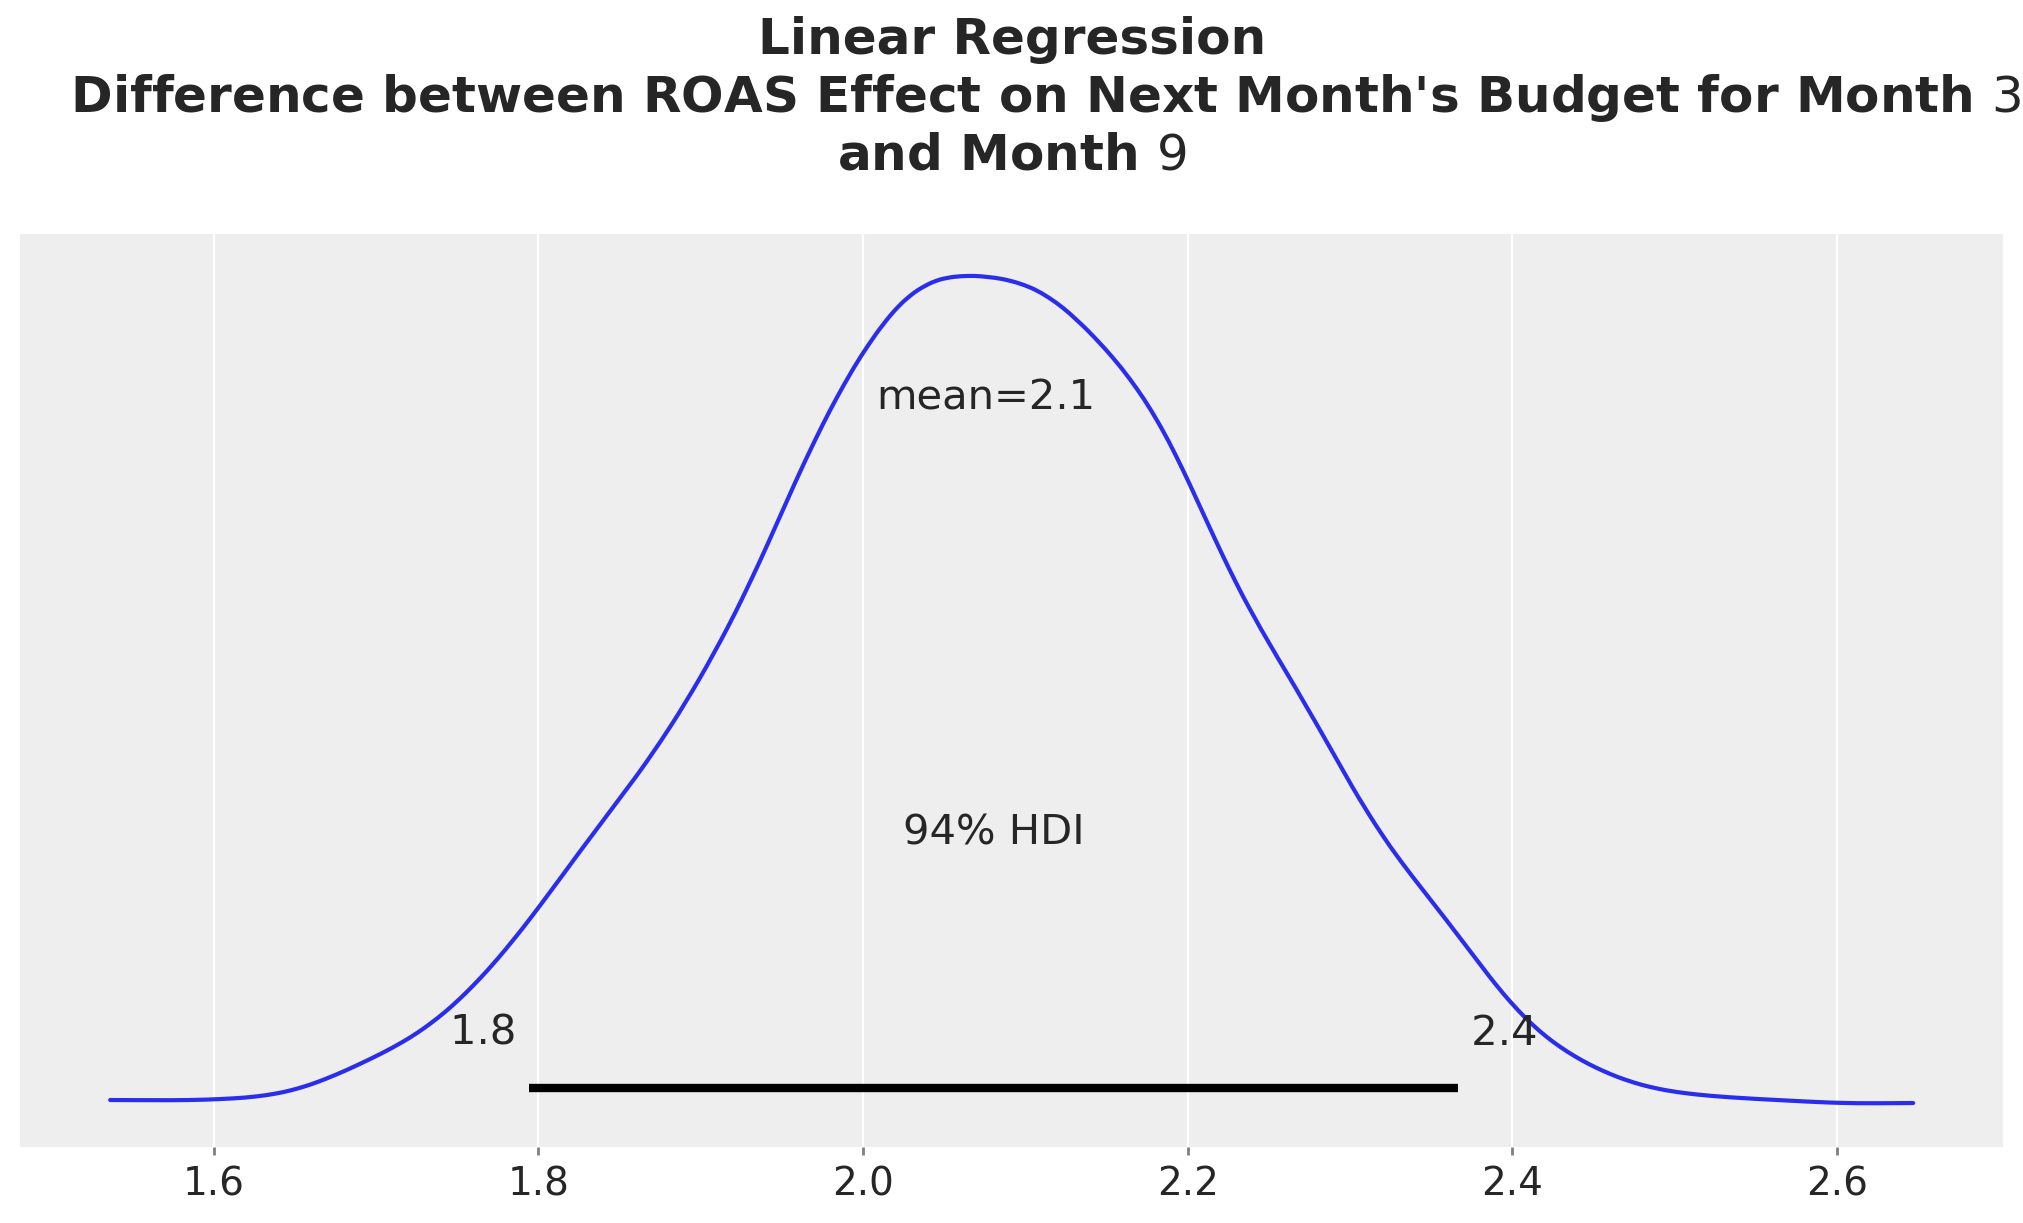

In [64]:
month_of_year_beta_0 = (
    idata_lm["posterior"]["C(month_of_year)"]
    .sel({"C(month_of_year)_dim": np.array([month_of_year_0], dtype="<U2")})
    .squeeze()
)

month_of_year_beta_1 = (
    idata_lm["posterior"]["C(month_of_year)"]
    .sel({"C(month_of_year)_dim": np.array([month_of_year_1], dtype="<U2")})
    .squeeze()
)

fig, ax = plt.subplots()
az.plot_posterior(month_of_year_beta_0 - month_of_year_beta_1, ax=ax)
ax.set_title(
    """Linear Regression
    Difference between ROAS Effect on Next Month's Budget for Month $3$ and Month $9$
    """,
    fontsize=18,
    fontweight="bold",
);

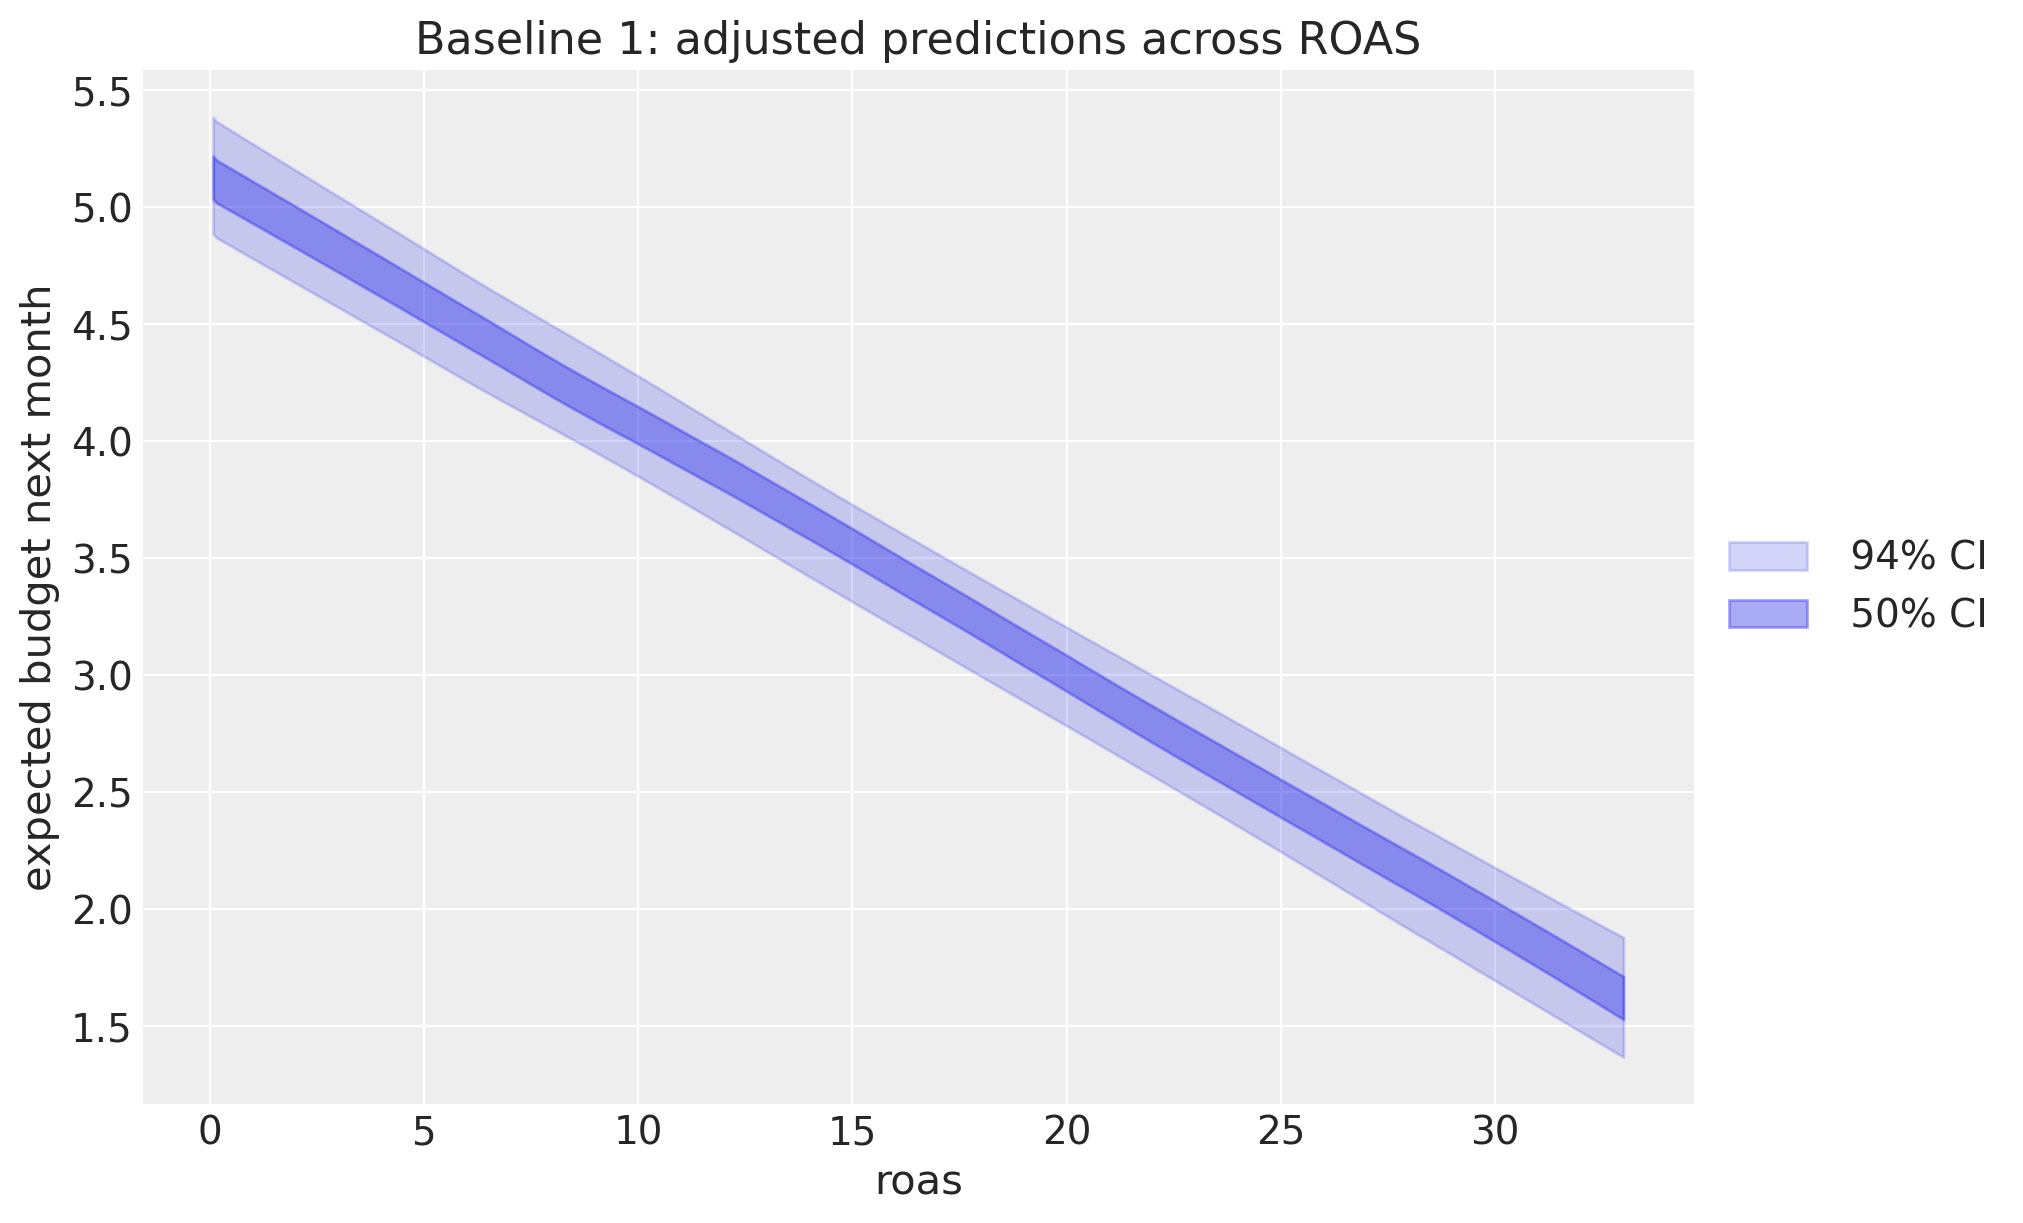

In [56]:
cohort_age_datagrid = datagrid(
    cohort_age=cohort_age_grid,
    month_of_year=np.mean(month_of_year_grid).round(),
    newdata=model_df,
)


idata_lm_mu_cohort_age_grid = predict_mu(model_lm, idata_lm, cohort_age_datagrid)

fig, ax = plt.subplots()


for j, hdi_prob in enumerate([0.94, 0.5]):
    az.plot_hdi(
        cohort_age_grid,
        idata_lm_mu_cohort_age_grid,
        hdi_prob=hdi_prob,
        color="C0",
        fill_kwargs={
            "alpha": 0.2 + 0.2 * j,
            "label": f"{hdi_prob: .0%} CI",
        },
        ax=ax,
    )
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))
ax.set(
    xlabel="roas",
    ylabel="expected budget next month",
    title="Baseline 1: adjusted predictions across ROAS",
);

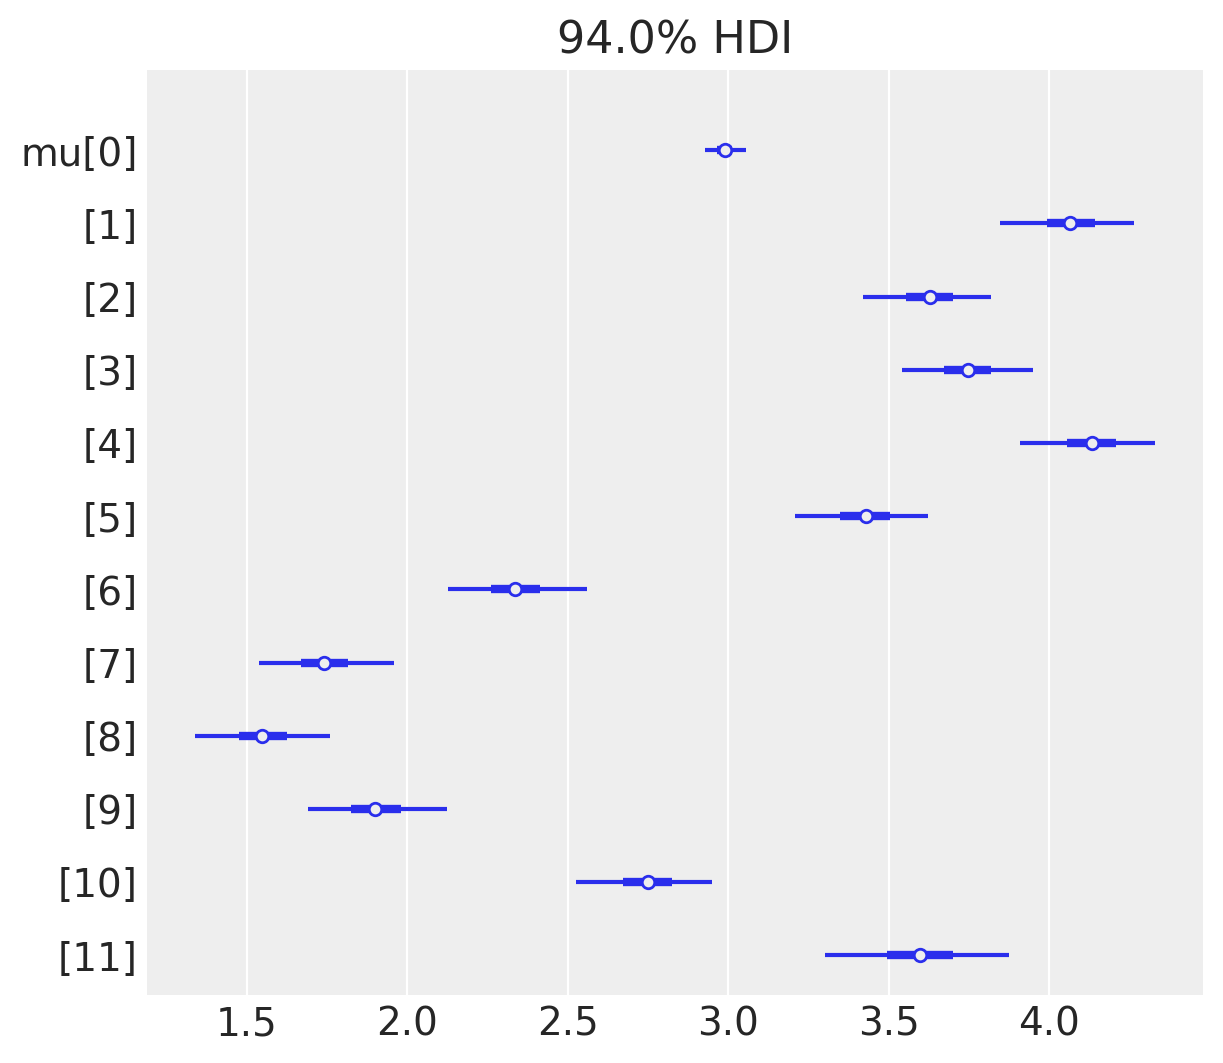

In [57]:
month_of_year_datagrid = datagrid(
    cohort_age=np.mean(cohort_age_grid).round(),
    month_of_year=month_of_year_grid,
    newdata=model_df,
)


idata_lm_mu_month_of_year_grid = predict_mu(model_lm, idata_lm, month_of_year_datagrid)

ax, *_ = az.plot_forest(idata_lm_mu_month_of_year_grid, combined=True)

The reason for this is because we are using a [`ZeroSumNormal`](https://www.pymc.io/projects/docs/en/5.24.1/api/distributions/generated/pymc.ZeroSumNormal.html) distribution for this categorical variable. This means that all the sum of the coefficients is also zero.

In [ ]:
az.plot_forest(idata_lm["posterior"]["C(month_of_year)"], combined=True)

## Baseline 2: Hurdle Gamma with a linear ROAS coefficient

Same likelihood family as the model we ultimately want, but ROAS still enters linearly on the log scale. The log link turns the linear coefficient into a *multiplicative* effect: `exp(linear)` is monotone, so we get a curve rather than a line, but no peak and no saturation. The shape is still wrong; the comparison versus the GP model will quantify how wrong.

In [ ]:
formula_hgl = bmb.Formula(
    "budget_next ~ 1 + cohort_age + C(month_of_year) + roas",
    "psi ~ 1 + cohort_age + C(month_of_year) + roas",
)

priors_hgl = {
    "Intercept": bmb.Prior("Normal", mu=0.0, sigma=1.0),
    "cohort_age": bmb.Prior("Normal", mu=0.0, sigma=1.0),
    "C(month_of_year)": bmb.Prior("Normal", mu=0.0, sigma=1.5),
    "roas": bmb.Prior("Normal", mu=0.0, sigma=1.0),
    "alpha": bmb.Prior("HalfNormal", sigma=1.0),
}

model_hgl = bmb.Model(
    formula=formula_hgl,
    data=df_fit,
    family="hurdle_gamma",
    link="log",
    priors=priors_hgl,
)
model_hgl.build()
model_hgl

### Prior predictive

In [ ]:
idata_prior_hgl = model_hgl.prior_predictive(draws=500, random_seed=seed)

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
az.plot_ppc(idata_prior_hgl, group="prior", ax=ax)
ax.set(
    title="Baseline 2: prior predictive",
)

### Fit

In [ ]:
idata_hgl = model_hgl.fit(
    draws=1000,
    tune=1000,
    chains=4,
    target_accept=0.95,
    inference_method="numpyro",
    random_seed=seed,
    idata_kwargs={"log_likelihood": True},
)

### Diagnostics

In [ ]:
az.summary(
    idata_hgl,
    var_names=["Intercept", "cohort_age", "C(month_of_year)", "roas", "alpha", "psi"],
    filter_vars="like",
)

In [ ]:
az.plot_trace(
    idata_hgl,
    var_names=[
        "Intercept",
        "cohort_age",
        "roas",
        "C(month_of_year)",
        "alpha",
        "psi_Intercept",
        "psi_cohort_age",
        "psi_C(month_of_year)",
        "psi_roas",
    ],
    compact=True,
    backend_kwargs={"layout": "constrained"},
)

In [ ]:
model_hgl.predict(idata_hgl, kind="response", inplace=True)

fig, ax = plt.subplots(figsize=(10, 5))
az.plot_ppc(idata_hgl, ax=ax)
ax.set(
    title="Baseline 2: posterior predictive",
)

### Adjusted predictions across ROAS

Monotone exponential of a linear slope. Better than baseline 1 (the right family and scale) but still wrong shape: no peak, no saturation.

In [ ]:
idata_hgl_mu_grid = predict_mu(model_hgl, idata_hgl, grid_roas)

fig, ax = plt.subplots(figsize=(12, 6))

for i, hdi_prob in enumerate([0.94, 0.5]):
    az.plot_hdi(
        roas_eval,
        idata_hgl_mu_grid,
        hdi_prob=hdi_prob,
        color="C0",
        fill_kwargs={"alpha": 0.2 + 0.2 * i, "label": f"{hdi_prob: .0%} CI"},
        ax=ax,
    )
ax.plot(roas_eval, truth_budget, color="black", linestyle="--", label="ground truth")
ax.set(
    xlabel="roas",
    ylabel="expected budget next month, given active",
    title="Baseline 2: adjusted predictions across ROAS",
)
ax.legend()

## GLM with varying coefficient: Hurdle Gamma + HSGP(roas)

Booked budget is non-negative with a real point-mass at zero (inactive months) and a positive continuous tail otherwise. **Hurdle Gamma** is the natural fit: a Bernoulli for "will the store spend at all next month", and a Gamma for "how much, given they spend". Bambi exposes it as `family="hurdle_gamma"`. By default the formula drives the Gamma mean and the zero-inflation probability $\psi$ is a single scalar; that's what we use here. Bambi lets you pass a multi-formula if a stakeholder wants different drivers per component.

The new piece is `hsgp(roas, ...)`, a Hilbert-space Gaussian-process basis on ROAS, in place of the linear `roas` term. We avoid assuming linearity, polynomial form, or knot locations; the GP lets the data shape the curve.

### Reading the formula

- `cohort_age` enters linearly. The DGP made it linear on `log_mu`, so a single coefficient is the right parameterization.
- `month_of_year` is a categorical (`C(...)`), 12 levels dummy-coded. Stakeholders think of "December lift" or "August dip", not sin/cos, so categorical contrasts read better.
- `hsgp(roas, ...)` is a Hilbert-space Gaussian-process basis on ROAS. We avoid assuming linearity, polynomial form, or knot locations; the GP lets the data shape the curve.

A subtlety: the DGP encodes ROAS as $\beta(\mathrm{roas}) \cdot \mathrm{roas}$, a *varying coefficient*. Bambi's formula API doesn't expose that directly. `hsgp(x, by=g)` supports group-specific GPs over a categorical `g`, but not a continuous-by-continuous product. The varying-coefficient form is straightforward in raw PyMC (see [bikes_gp](https://juanitorduz.github.io/bikes_gp/)). For this talk we keep things in pure Bambi: a single `hsgp(roas)` is flexible enough to absorb $\beta(\mathrm{roas}) \cdot \mathrm{roas}$ as one smooth $g(\mathrm{roas})$, and we'll recover $\hat{\beta}(\mathrm{roas})$ post-hoc.

In [ ]:
HSGP_M = 20
HSGP_C = 1.5

formula = bmb.Formula(
    f"budget_next ~ 1 + cohort_age + C(month_of_year) + hsgp(roas, m={HSGP_M}, c={HSGP_C})",
    f"psi ~ 1 + cohort_age + C(month_of_year) + hsgp(roas, m={HSGP_M}, c={HSGP_C})",
)

priors = {
    "Intercept": bmb.Prior("Normal", mu=0.0, sigma=1.0),
    "cohort_age": bmb.Prior("Normal", mu=0.0, sigma=1.0),
    "C(month_of_year)": bmb.Prior("ZeroSumNormal", sigma=1.5),
    "alpha": bmb.Prior("HalfNormal", sigma=1.0),
    "psi": {
        "C(month_of_year)": bmb.Prior("ZeroSumNormal", sigma=1.5),
    },
}

model = bmb.Model(
    formula=formula, data=df_fit, family="hurdle_gamma", link="log", priors=priors
)
model.build()
model

## Prior predictive check

Are the implied budgets in a sensible order of magnitude before the data is touched?

In [ ]:
idata_prior = model.prior_predictive(draws=500, random_seed=seed)

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
az.plot_ppc(idata_prior, group="prior", ax=ax)
ax.set(
    title="Prior predictive",
)

## Fit

In [ ]:
idata = model.fit(
    draws=1000,
    tune=1000,
    chains=4,
    target_accept=0.95,
    inference_method="numpyro",
    random_seed=seed,
    idata_kwargs={"log_likelihood": True},
)

## Diagnostics

In [ ]:
az.summary(
    idata,
    var_names=["Intercept", "cohort_age", "C(month_of_year)", "alpha", "psi"],
    filter_vars="like",
)

In [ ]:
az.plot_trace(
    idata,
    var_names=[
        "Intercept",
        "cohort_age",
        "C(month_of_year)",
        "alpha",
        "psi_Intercept",
        "psi_cohort_age",
        "psi_C(month_of_year)",
        "psi_roas",
    ],
    compact=True,
    backend_kwargs={"layout": "constrained"},
)

In [ ]:
model.predict(idata, kind="response", inplace=True)

fig, ax = plt.subplots(figsize=(10, 5))
az.plot_ppc(idata, ax=ax)
ax.set(
    title="Posterior predictive",
    xlim=(0, np.quantile(df_fit["budget_next"], 0.99) * 2),
)

## Why raw coefficients don't answer the question

`az.summary` gives us posterior means of the model parameters: an intercept, a `cohort_age` slope, eleven contrasts for the months, and a basket of HSGP basis weights. None of these answer the question a stakeholder actually asks:

> *"If a store's ROAS goes from 2 to 3 next month, how much more budget will they book?"*

The log link makes the intercept a multiplicative offset, the categorical contrasts are differences against a baseline month, and the HSGP weights have no individual meaning. We need to ask the model directly, in the units of the data.

## Quantities of interest, by hand

The [`marginaleffects`](https://marginaleffects.com/) framework names three primitives:

- **`predictions`**: what does the model say at this scenario?
- **`comparisons`**: what changes when we move from A to B?
- **`slopes`**: what is $\partial \hat{Y} / \partial X$ here? (we'll skip this one in the walkthrough; it's the same recipe with a finite-difference twist on top.)

We'll build the first two ourselves so the mechanics are visible. The recipe is always the same: pick a reference grid, push it through the posterior, summarise. The Python `marginaleffects` package would automate this for `statsmodels` / `sklearn` / `linearmodels` / `pyfixest` models, but Bambi/PyMC isn't on its supported list yet, so rolling it ourselves is also the only path.

### Adjusted predictions across ROAS

Reuse the shared `grid_roas` (ROAS sweep at cohort age 12, month-of-year June) and the Gamma-conditional `truth_budget` defined earlier.

In [ ]:
roas_eval = np.linspace(0.2, 6.0, 60)
grid_roas = pl.DataFrame(
    {
        "roas": roas_eval,
        "cohort_age": np.full_like(roas_eval, 12, dtype=np.int64),
        "month_of_year": np.full_like(roas_eval, 12, dtype=np.int64),
    }
)

truth_log_mu = (
    params.intercept
    + season(np.full_like(roas_eval, 6))
    + params.cohort_slope * 12
    + f_roas(roas_eval)
)
truth_budget = np.exp(truth_log_mu)

idata_mu_grid = predict_mu(model, idata, grid_roas)

fig, ax = plt.subplots(figsize=(12, 6))

for i, hdi_prob in enumerate([0.94, 0.5]):
    az.plot_hdi(
        roas_eval,
        idata_mu_grid,
        hdi_prob=hdi_prob,
        color="C0",
        fill_kwargs={"alpha": 0.2 + 0.2 * i, "label": f"{hdi_prob: .0%} CI"},
        ax=ax,
    )
ax.plot(roas_eval, truth_budget, color="black", linestyle="--", label="ground truth")
ax.set(
    xlabel="roas",
    ylabel="expected budget next month, given active",
    title="Adjusted predictions across ROAS (cohort_age=12, month=6)",
)
ax.legend()

The recovered curve tracks the ground truth: shallow for low ROAS, climbing through break-even, levelling off past 4. We're plotting the **Gamma-conditional** mean here (expected budget *given* the store spends); the hurdle's $\psi$ scales it down to the unconditional expectation later on.

### Recovering $\hat{\beta}(\text{roas})$ post-hoc

We modelled ROAS as a single smooth $g(\text{roas})$ on the log scale, but the DGP wrote it as $\beta(\text{roas}) \cdot \text{roas}$. We can recover $\hat{\beta}$ by isolating the GP contribution to $\log \mu$ (everything else cancels when we hold cohort age and month fixed) and dividing by ROAS.

One number, on the response scale, with uncertainty attached: exactly the language the platform team would use.

### Cohort-age effect

In [ ]:
ages = np.arange(0, params.n_months)
grid_age = pl.DataFrame(
    {
        "roas": np.full_like(ages, 2.5, dtype=float),
        "cohort_age": ages,
        "month_of_year": np.full_like(ages, 6),
    }
)
mu_age = predict_mu(model, idata, grid_age)

fig, ax = plt.subplots(figsize=(12, 6))

for i, hdi_prob in enumerate([0.94, 0.5]):
    az.plot_hdi(
        ages,
        mu_age,
        hdi_prob=hdi_prob,
        color="C0",
        fill_kwargs={"alpha": 0.2 + 0.2 * i, "label": f"{hdi_prob: .0%} CI"},
        ax=ax,
    )
ax.legend()
ax.set(
    xlabel="cohort age (months)",
    ylabel="expected budget next month",
    title="Cohort-age effect (roas=2.5, month=6)",
)

### Yearly seasonality

In [ ]:
months = np.arange(1, 13)
grid_month = pl.DataFrame(
    {
        "roas": np.full_like(months, 2.5, dtype=float),
        "cohort_age": np.full_like(months, 12),
        "month_of_year": months,
    }
)

mu_month = predict_mu(model, idata, grid_month)

fig, ax = plt.subplots(figsize=(12, 6))

for i, hdi_prob in enumerate([0.94, 0.5]):
    az.plot_hdi(
        months,
        mu_month,
        hdi_prob=hdi_prob,
        color="C0",
        fill_kwargs={"alpha": 0.2 + 0.2 * i, "label": f"{hdi_prob: .0%} CI"},
        ax=ax,
    )
ax.legend()
ax.set(
    xlabel="cohort age (months)",
    ylabel="expected budget next month",
    title="Cohort-age effect (roas=2.5, month=6)",
)
# ax.plot(
#     months, truth_month, color="black", linestyle="--", marker="o", label="ground truth"
# )
ax.set(
    xticks=months,
    xlabel="month of year",
    ylabel="expected budget next month",
    title="Seasonality (roas=2.5, cohort_age=12)",
)
ax.legend()

## The same answers via Bambi's `interpret` module

Now that we've seen the mechanics, here's what you'd actually write day to day. Bambi ships [interpretation tools](https://bambinos.github.io/bambi/notebooks/#tools-to-interpret-model-outputs) with the same three primitives, driven by a `conditional` dictionary in place of the polars grids we built by hand.

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
bmb.interpret.plot_predictions(
    model,
    idata,
    conditional={"roas": roas_eval, "cohort_age": 12, "month_of_year": 6},
    ax=ax,
)
ax.set_title("bmb.interpret.plot_predictions: across ROAS")

In [ ]:
bmb.interpret.comparisons(
    model,
    idata,
    contrast={"roas": [1.0, 4.0]},
    conditional={"cohort_age": 12, "month_of_year": 6},
)

Same shapes, same intervals, three lines instead of thirty. Worth knowing both: the by-hand version is the one to reach for when the question doesn't fit a built-in primitive.

## Model comparison and parameter recovery

Three models, same fit dataframe, same evaluation grid. Two questions:

1. Which one generalises best out-of-sample? `az.compare` with leave-one-out (LOO).
2. Which one actually recovers the truth? We put the ROAS curve, the cohort slope, the seasonality, and $\beta(\mathrm{roas})$ next to their ground-truth values side by side.

### Leave-one-out cross-validation

Lower `elpd_loo` is worse. The hurdle-Gamma + HSGP model should sit at the top with `elpd_diff = 0`; the linear hurdle-Gamma beats the linear Gaussian thanks to the right family and the log link.

In [ ]:
compare_df = az.compare(
    {
        "linear_gaussian": idata_lm,
        "linear_hgamma": idata_hgl,
        "vc_hgamma": idata,
    },
    ic="loo",
)
compare_df

In [ ]:
az.plot_compare(compare_df, insample_dev=False)